# Modelado con LightGBM 
Revised

## 0. Setup

In [1]:
# %pip install lightgbm optuna

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pathlib
warnings.filterwarnings('ignore')

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

plt.rcParams['figure.dpi'] = 110

print('Imports OK')
print(f'LightGBM: {lgb.__version__}')
print(f'Optuna:   {optuna.__version__}')

Imports OK
LightGBM: 4.6.0
Optuna:   4.9.0


In [1]:
from pathlib import Path

# ============================================================
# Directorio único de guardado de gráficos y tablas del proyecto
# ============================================================

directorio_salidas_proyecto = Path(
    r"C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos"
)

directorio_salidas_proyecto.mkdir(
    parents=True,
    exist_ok=True
)

print("Directorio de salida:", directorio_salidas_proyecto)
print("Existe:", directorio_salidas_proyecto.exists())

Directorio de salida: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos
Existe: True


## 1. Carga de datos

In [3]:
#df = pd.read_csv('dataset_7000_53.csv')

df = pd.read_csv("dataset_4913_53.csv") #dataset con target sin NA

print(f'Shape: {df.shape}')
print(f"n_shows_24_25 — con dato: {df['n_shows_24_25'].notna().sum()}  "
      f"sin dato: {df['n_shows_24_25'].isna().sum()}")
df[['artist_name','sp_monthly_listeners','ins_followers','n_shows_24_25']].head(3)

Shape: (4913, 53)
n_shows_24_25 — con dato: 4913  sin dato: 0


,artist_name,sp_monthly_listeners,ins_followers,n_shows_24_25
0,Bad Bunny,112734492.0,54721804.0,45
1,Taylor Swift,102733014.0,280531827.0,49
2,Bruno Mars,134166866.0,42922145.0,55


# dimensiones variables


In [4]:
# Agrupación conceptual de variables
# Construcción de diccionario de variables

id_cols = [
    "chartmetric_id",
    "artist_name"
]

metadata_cols = [
    "country",
    "country_short",
    "pronoun_title",
    "pronoun_short",
    "record_label",
    "major_record_label",
    "primary_genre",
    "genre_short",
    "band",
    "muerto_disuelto"
]

streaming_cols = [
    "sp_followers",
    "sp_monthly_listeners",
    "sp_popularity",
    "deezer_fans",
    "shazam_count",
    "pandora_lifetime_streams",
    "pandora_lifetime_stations_added"
]

playlist_cols = [
    "sp_playlist_total_reach",
    "num_sp_editorial_playlists",
    "num_sp_playlists",
    "sp_editorial_playlist_total_reach",
    "num_am_editorial_playlists",
    "num_am_playlists",
    "num_de_editorial_playlists",
    "num_de_playlists",
    "de_playlist_total_reach",
    "de_editorial_playlist_total_reach",
    "num_az_editorial_playlists",
    "num_az_playlists",
    "num_yt_editorial_playlists",
    "num_yt_playlists",
    "yt_playlist_total_reach"
]

social_cols = [
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_likes",
    "tiktok_top_video_views",
    "tiktok_top_video_comments",
    "tiktok_track_posts"
]

youtube_cols = [
    "ycs_subscribers",
    "ycs_views",
    "youtube_daily_video_views",
    "youtube_monthly_video_views"
]

live_cols = [
    "n_shows_24_25",
    "n_shows_with_capacity_24_25",
    "capacity_24_25",
    "avg_venue_capacity_24_25",
    "n_cities_24_25",
    "n_countries_24_25",
    "shows_per_country_24_25",
    "off_cycle"
]


# Diccionario de dimensiones
column_groups = {
    "identificacion": id_cols,
    "metadata": metadata_cols,
    "streaming": streaming_cols,
    "playlists": playlist_cols,
    "redes_sociales": social_cols,
    "youtube": youtube_cols,
    "live_events": live_cols
}

# ============================================================
# Tabla auxiliar con identidad conceptual de cada variable
# ============================================================

variable_dimension = []

for dimension, cols in column_groups.items():
    for col in cols:
        variable_dimension.append({
            "variable": col,
            "dimension": dimension
        })

df_variable_dimension = pd.DataFrame(variable_dimension)

# ============================================================
# Control de cobertura de columnas
# ============================================================

grouped_cols = df_variable_dimension["variable"].tolist()

cols_in_groups_not_in_df = sorted(set(grouped_cols) - set(df.columns))
cols_in_df_not_in_groups = sorted(set(df.columns) - set(grouped_cols))

print("Columnas del df:", df.shape[1])
print("Columnas agrupadas:", len(grouped_cols))
print("Columnas agrupadas que no están en df:", cols_in_groups_not_in_df)
print("Columnas del df no agrupadas:", cols_in_df_not_in_groups)

# ============================================================
# Resumen por dimensión
# ============================================================

resumen_dimensiones = (
    df_variable_dimension
    .groupby("dimension", as_index=False)
    .agg(n_variables=("variable", "count"))
    .sort_values("n_variables", ascending=False)
)

display(resumen_dimensiones)

# ============================================================
# Vista del diccionario de variables
# ============================================================

display(df_variable_dimension)

Columnas del df: 53
Columnas agrupadas: 53
Columnas agrupadas que no están en df: []
Columnas del df no agrupadas: []


,dimension,n_variables
3,playlists,15
2,metadata,10
1,live_events,8
5,streaming,7
4,redes_sociales,7
6,youtube,4
0,identificacion,2


,variable,dimension
0,chartmetric_id,identificacion
1,artist_name,identificacion
2,country,metadata
3,country_short,metadata
4,pronoun_title,metadata
5,pronoun_short,metadata
6,record_label,metadata
7,major_record_label,metadata
8,primary_genre,metadata
9,genre_short,metadata


# tipos datos

In [5]:
# 1. Definir el diccionario de tipos

# agregar los ratios en el diccionario

dtypes_dict = {
    'chartmetric_id': 'Int64',
    'artist_name': 'str',
    'country': 'category',
    'pronoun_title': 'category',
    'record_label': 'category',
    'primary_genre': 'category',
    'sp_followers': 'Int64',
    'sp_monthly_listeners': 'Int64',
    'sp_popularity': 'float64',
    'sp_playlist_total_reach': 'float64',
    'ins_followers': 'Int64',
    'twitter_followers': 'Int64',
    'tiktok_followers': 'Int64',
    'tiktok_likes': 'Int64',
    'ycs_subscribers': 'Int64',
    'ycs_views': 'Int64',
    'youtube_daily_video_views': 'Int64',
    'youtube_monthly_video_views': 'Int64',
    'deezer_fans': 'Int64',
    'shazam_count': 'Int64',
    'pandora_lifetime_streams': 'Int64',
    'pandora_lifetime_stations_added': 'Int64',
    'band': 'bool',
    'num_sp_editorial_playlists': 'Int64',
    'num_sp_playlists': 'Int64',
    'sp_editorial_playlist_total_reach': 'float64',
    'num_am_editorial_playlists': 'Int64',
    'num_am_playlists': 'Int64',
    'num_de_editorial_playlists': 'Int64',
    'num_de_playlists': 'Int64',
    'de_playlist_total_reach': 'float64',
    'de_editorial_playlist_total_reach': 'float64',
    'num_az_editorial_playlists': 'Int64',
    'num_az_playlists': 'Int64',
    'num_yt_editorial_playlists': 'Int64',
    'num_yt_playlists': 'Int64',
    'yt_playlist_total_reach': 'float64',
    'tiktok_top_video_views': 'float64',
    'tiktok_top_video_comments': 'float64',
    'tiktok_track_posts': 'float64',
    'n_shows_24_25': 'Int64',
    'n_shows_with_capacity_24_25': 'Int64',
    'capacity_24_25': 'float64',
    'avg_venue_capacity_24_25': 'float64',
    'n_cities_24_25': 'Int64',
    'n_countries_24_25': 'Int64',
    'shows_per_country_24_25': 'float64',
    'major_record_label': 'boolean',
    'pronoun_short': 'category',
    'genre_short': 'category',
    'country_short': 'category',
    'off_cycle': 'bool',
    'muerto_disuelto': 'boolean'
}

# Aplicar la conversión al dataframe df

# Conversión solo de columnas existentes
dtypes_presentes = {
    col: dtype
    for col, dtype in dtypes_dict.items()
    if col in df.columns
}

df = df.astype(dtypes_presentes)

# 3. Verificación rápida
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   chartmetric_id                     4913 non-null   Int64   
 1   artist_name                        4913 non-null   str     
 2   country                            4909 non-null   category
 3   pronoun_title                      4913 non-null   category
 4   record_label                       4604 non-null   category
 5   primary_genre                      4913 non-null   category
 6   sp_followers                       4907 non-null   Int64   
 7   sp_monthly_listeners               4907 non-null   Int64   
 8   sp_popularity                      4911 non-null   float64 
 9   sp_playlist_total_reach            4913 non-null   float64 
 10  ins_followers                      4580 non-null   Int64   
 11  twitter_followers                  3968 non-null   Int

In [6]:
# Estructura general del dataset
print("Filas y columnas:", df.shape)

# Control de clave única
print("Artistas únicos:", df["chartmetric_id"].nunique())
print("Duplicados por chartmetric_id:", df.duplicated(subset="chartmetric_id").sum())

# Control de target
print("Nulos en target:", df["n_shows_24_25"].isna().sum())
print("Tipo de dato de target:", df["n_shows_24_25"].dtype)

Filas y columnas: (4913, 53)
Artistas únicos: 4913
Duplicados por chartmetric_id: 0
Nulos en target: 0
Tipo de dato de target: Int64


# 2. Feature Engineering

In [7]:
# ── 2a. Target: log1p(n_shows_24_25) ─────────────────────────────────────────
TARGET = "n_shows_24_25"

y_all = df[TARGET].astype(float).values

assert np.all(y_all >= 0), "El target para Poisson/Tweedie debe ser no negativo."
assert not np.isnan(y_all).any(), "El target no debería tener valores faltantes."


print(f"Target shape : {y_all.shape}")
print(f"Target range : [{y_all.min():.3f}, {y_all.max():.3f}]")
print(f"Target mean  : {y_all.mean():.3f}  |  median: {np.median(y_all):.3f}")

Target shape : (4913,)
Target range : [0.000, 179.000]
Target mean  : 24.299  |  median: 13.000


In [8]:
# ── 2b. Log1p transforms + ratio features ────────────────────────────────────
#
# LightGBM is tree-based (invariant to monotone transforms on features),
# but log1p compresses extreme tails and produces better histogram bins
# when max_bin=31 (coarse discretisation — bin quality matters here).
# sp_popularity is already 0-100: no transform needed.
# Boolean / category columns: no transform needed.

vars_log1p = (
    [c for c in streaming_cols  if c != 'sp_popularity']
    + playlist_cols
    + social_cols
    + youtube_cols
)

df_fe = df.copy()

for col in vars_log1p:
    df_fe[col] = np.log1p(df_fe[col].astype(float))

# Log-ratio features (log(a/b) = log(a) - log(b) — avoids division by zero)
df_fe['log_ins_sp_ratio']     = (np.log1p(df['ins_followers'].astype(float))
                                  - np.log1p(df['sp_monthly_listeners'].astype(float)))
df_fe['log_tiktok_sp_ratio']  = (np.log1p(df['tiktok_top_video_comments'].astype(float))
                                  - np.log1p(df['sp_monthly_listeners'].astype(float)))
df_fe['log_youtube_sp_ratio'] = (np.log1p(df['ycs_views'].astype(float))
                                  - np.log1p(df['sp_monthly_listeners'].astype(float)))

ratio_cols = ['log_ins_sp_ratio', 'log_tiktok_sp_ratio', 'log_youtube_sp_ratio']

print("Log1p applied to:", len(vars_log1p), "variables")
print("Ratio features created:", ratio_cols)

Log1p applied to: 32 variables
Ratio features created: ['log_ins_sp_ratio', 'log_tiktok_sp_ratio', 'log_youtube_sp_ratio']


In [9]:
# ── 2c. Feature matrix: campos_buenos ────────────────────────────────────────
#
# Exclude:
#   • identifiers            : chartmetric_id, artist_name
#   • target                 : n_shows_24_25
#   • leakage (live events)  : all other live_cols
#   • target-construction aid: muerto_disuelto
#   • high-cardinality cols  : country, pronoun_title, record_label, primary_genre
#                              (replaced by _short reduced-cardinality versions)
# y ratios

LEAKAGE_COLS = [
    'n_shows_with_capacity_24_25',
    'capacity_24_25',
    'avg_venue_capacity_24_25',
    'n_cities_24_25',
    'n_countries_24_25',
    'shows_per_country_24_25',
    'off_cycle',
    'muerto_disuelto',
]
HIGH_CARD_COLS = ['country', 'pronoun_title', 'record_label', 'primary_genre']
EXCLUDE_COLS   = id_cols + [TARGET] + LEAKAGE_COLS + HIGH_CARD_COLS

campos_buenos = [c for c in df_fe.columns if c not in EXCLUDE_COLS]

# ── Categóricas nativas para LightGBM ───────────────────────────────────────
CAT_COLS = ['country_short', 'pronoun_short', 'genre_short']
CAT_COLS = [c for c in CAT_COLS if c in campos_buenos]

for col in CAT_COLS:
    df_fe[col] = df_fe[col].astype('category')

# ── Convertir booleanas predictoras a float de forma compatible con NaN ──────
BOOL_COLS = ['band', 'major_record_label']
BOOL_COLS = [c for c in BOOL_COLS if c in campos_buenos]

for col in BOOL_COLS:
    df_fe[col] = df_fe[col].astype(float)

# ── Convertir columnas numéricas del modelo a float ─────────────────────────
# Se evita que LightGBM reciba dtypes extension de pandas como Int64/boolean.
NUMERIC_MODEL_COLS = [c for c in campos_buenos if c not in CAT_COLS]
for col in NUMERIC_MODEL_COLS:
    df_fe[col] = df_fe[col].astype(float)

# ── Matriz final de features ────────────────────────────────────────────────
# Se conserva como DataFrame para que LightGBM reconozca columnas categóricas.
X_all = df_fe[campos_buenos].copy()

print(f"campos_buenos : {len(campos_buenos)} features")
print(f"X_all shape   : {X_all.shape}")
print(f"y_all shape   : {y_all.shape}")
print(f"\nCategorical features passed to LightGBM: {CAT_COLS}")

# Quick null audit
null_pct = X_all.isna().mean().sort_values(ascending=False)
print("\nTop-10 null rates:")
print(null_pct.head(10).round(3).to_string())

assert TARGET not in campos_buenos, "La target quedó incluida entre las predictoras."
assert 'muerto_disuelto' not in campos_buenos, "muerto_disuelto debe quedar excluida del modelo supervisado."
assert not any(col in campos_buenos for col in LEAKAGE_COLS), "Hay variables de leakage entre las predictoras."


campos_buenos : 41 features
X_all shape   : (4913, 41)
y_all shape   : (4913,)

Categorical features passed to LightGBM: ['country_short', 'pronoun_short', 'genre_short']

Top-10 null rates:
youtube_daily_video_views      0.308
youtube_monthly_video_views    0.308
tiktok_likes                   0.266
tiktok_followers               0.266
twitter_followers              0.192
log_ins_sp_ratio               0.069
ins_followers                  0.068
major_record_label             0.063
log_youtube_sp_ratio           0.051
ycs_subscribers                0.049


In [10]:
# ============================================================
# Sanity check de matriz final de features
# ============================================================

print("Shape X_all:", X_all.shape)
print("Cantidad de features:", len(campos_buenos))

print("\nRatios presentes en campos_buenos:")
print([col for col in ratio_cols if col in campos_buenos])

print("\nLeakage presente en campos_buenos:")
print([col for col in LEAKAGE_COLS if col in campos_buenos])

print("\nNaN por columna en X_all:")
na_por_columna = (
    X_all.isna()
    .sum()
    .sort_values(ascending=False)
)

display(na_por_columna[na_por_columna > 0])

print("\nTipos de datos en X_all:")
display(X_all.dtypes.value_counts())

Shape X_all: (4913, 41)
Cantidad de features: 41

Ratios presentes en campos_buenos:
['log_ins_sp_ratio', 'log_tiktok_sp_ratio', 'log_youtube_sp_ratio']

Leakage presente en campos_buenos:
[]

NaN por columna en X_all:


youtube_daily_video_views            1512
youtube_monthly_video_views          1512
tiktok_likes                         1309
tiktok_followers                     1309
twitter_followers                     945
log_ins_sp_ratio                      339
ins_followers                         333
major_record_label                    309
log_youtube_sp_ratio                  249
ycs_subscribers                       243
ycs_views                             243
num_az_editorial_playlists            238
num_az_playlists                      238
pandora_lifetime_stations_added       149
yt_playlist_total_reach               141
de_playlist_total_reach               102
de_editorial_playlist_total_reach     102
num_de_playlists                      102
num_de_editorial_playlists            102
pandora_lifetime_streams               96
num_yt_editorial_playlists             94
num_yt_playlists                       94
deezer_fans                            60
num_am_editorial_playlists        


Tipos de datos en X_all:


float64     38
category     1
category     1
category     1
Name: count, dtype: int64

In [11]:
campos_buenos

['sp_followers',
 'sp_monthly_listeners',
 'sp_popularity',
 'sp_playlist_total_reach',
 'ins_followers',
 'twitter_followers',
 'tiktok_followers',
 'tiktok_likes',
 'ycs_subscribers',
 'ycs_views',
 'youtube_daily_video_views',
 'youtube_monthly_video_views',
 'deezer_fans',
 'shazam_count',
 'pandora_lifetime_streams',
 'pandora_lifetime_stations_added',
 'band',
 'num_sp_editorial_playlists',
 'num_sp_playlists',
 'sp_editorial_playlist_total_reach',
 'num_am_editorial_playlists',
 'num_am_playlists',
 'num_de_editorial_playlists',
 'num_de_playlists',
 'de_playlist_total_reach',
 'de_editorial_playlist_total_reach',
 'num_az_editorial_playlists',
 'num_az_playlists',
 'num_yt_editorial_playlists',
 'num_yt_playlists',
 'yt_playlist_total_reach',
 'tiktok_top_video_views',
 'tiktok_top_video_comments',
 'tiktok_track_posts',
 'major_record_label',
 'pronoun_short',
 'genre_short',
 'country_short',
 'log_ins_sp_ratio',
 'log_tiktok_sp_ratio',
 'log_youtube_sp_ratio']

# 3. PARAM — semillas y configuración del experimento

Todas las semillas se extraen de números primos.

In [12]:
# ── 3a. PARAM global ─────────────────────────────────────────────────────────
PARAM = {}
PARAM['experimento']        = 'lgbm-poisson'
PARAM['semilla_primigenia'] = 102191

# Bayesian Optimisation
# Cada trial se evalúa con 10 semillas desde el inicio del workflow.
PARAM['BO'] = {
    'iteraciones'  : 100,
    'ksemillerio'  : 10,
    'repe'         : 1,
}

# Evaluación final sobre holdout
PARAM['train_final'] = {
    'APO'        : 5,
    'ksemillerio': 20,
}

assert PARAM['BO']['ksemillerio'] * PARAM['BO']['repe'] == 10, "BO debe evaluar cada trial con 10 semillas."
assert PARAM['train_final']['APO'] * PARAM['train_final']['ksemillerio'] == 100, "La evaluación final debe usar 100 semillas."

print("PARAM OK")
print(f"  BO        : {PARAM['BO']['iteraciones']} trials × "
      f"{PARAM['BO']['repe']} reps × {PARAM['BO']['ksemillerio']} seeds = "
      f"{PARAM['BO']['iteraciones'] * PARAM['BO']['repe'] * PARAM['BO']['ksemillerio']} fits")
print(f"  Final     : {PARAM['train_final']['APO']} APO × "
      f"{PARAM['train_final']['ksemillerio']} seeds = "
      f"{PARAM['train_final']['APO'] * PARAM['train_final']['ksemillerio']} fits")


PARAM OK
  BO        : 100 trials × 1 reps × 10 seeds = 1000 fits
  Final     : 5 APO × 20 seeds = 100 fits


In [13]:
# ── 3b. Pool de primos + distribución de semillas ────────────────────────────
# Equivalente exacto de generate_primes(100000, 1000000) + sample().
# Se usa criba de Eratóstenes (sin dependencias externas).

def sieve_primes(min_val, max_val):
    sieve = bytearray([1]) * (max_val + 1)
    sieve[0] = sieve[1] = 0
    for i in range(2, int(max_val**0.5) + 1):
        if sieve[i]:
            sieve[i*i::i] = bytearray(len(range(i*i, max_val + 1, i)))
    return [i for i in range(max(2, min_val), max_val + 1) if sieve[i]]

primos = sieve_primes(100_000, 1_000_000)
print(f"Primos disponibles [100K, 1M]: {len(primos):,}")

# Todas las semillas se sortean de una vez con la semilla primigenia
rng = np.random.default_rng(PARAM['semilla_primigenia'])

n_bo_seeds    = PARAM['BO']['ksemillerio'] * PARAM['BO']['repe']
n_final_seeds = PARAM['train_final']['APO'] * PARAM['train_final']['ksemillerio']

all_seeds = rng.choice(primos, size=n_bo_seeds + n_final_seeds, replace=False).tolist()

PARAM['BO']['semillas']           = all_seeds[:n_bo_seeds]
PARAM['train_final']['semillas']  = all_seeds[n_bo_seeds:]

print(f"\nSemillas BO ({n_bo_seeds}):      {PARAM['BO']['semillas']}")
print(f"Semillas finales ({n_final_seeds}) — primeras 5: {PARAM['train_final']['semillas'][:5]}")

Primos disponibles [100K, 1M]: 68,906

Semillas BO (10):      [729661, 343529, 136481, 228251, 227629, 822803, 432737, 655727, 664579, 917051]
Semillas finales (100) — primeras 5: [306419, 503407, 103471, 116201, 107197]


In [14]:
# ── 3c. Parámetros fijos de LightGBM ─────────────────────────────────────────
# Traducción directa de PARAM$lgbm$param_fijos.
# objective y metric cambian a regresión (pre usaba binary/custom).

PARAM['lgbm'] = {
    'param_fijos': {
        'objective'          : 'poisson',
        'metric'             : 'poisson',
        'first_metric_only'  : True,
        'boost_from_average' : True,
        'feature_pre_filter' : False,
        'verbosity'          : -1,
        'force_row_wise'     : True,
        'extra_trees'        : False,
        'max_depth'          : -1,
        'min_gain_to_split'  : 0.0,
        'min_sum_hessian_in_leaf': 0.001,
        'lambda_l1'          : 0.0,
        'lambda_l2'          : 0.0,
        'bagging_fraction'   : 1.0,
        'is_unbalance'       : False,
        'max_bin'            : 31,
        'num_threads'        : 4,
    }
}

print("Parámetros fijos LightGBM:")
for k, v in PARAM['lgbm']['param_fijos'].items():
    print(f"  {k:<28} = {v}")

Parámetros fijos LightGBM:
  objective                    = poisson
  metric                       = poisson
  first_metric_only            = True
  boost_from_average           = True
  feature_pre_filter           = False
  verbosity                    = -1
  force_row_wise               = True
  extra_trees                  = False
  max_depth                    = -1
  min_gain_to_split            = 0.0
  min_sum_hessian_in_leaf      = 0.001
  lambda_l1                    = 0.0
  lambda_l2                    = 0.0
  bagging_fraction             = 1.0
  is_unbalance                 = False
  max_bin                      = 31
  num_threads                  = 4


# 4. Splits

**Outer split** — df_dev (70 %) / df_holdout (30 %):  
El holdout nunca se toca durante Optuna. Rol: *sanity check* de que el modelo aprendió algo real antes de interpretar los importances. Equivalente al `future = 202106` del profesor.

**Inner split** — df_bo_train / df_bo_val (70/30 dentro del dev):  
Todos los 100 trials de Optuna evalúan contra el mismo df_bo_val fijo.  
Equivalente al `testing = 202104` del profesor.

In [15]:
# ── 4a. Outer split: dev (70%) / holdout (30%) ───────────────────────────────
# Estratificado por quintiles del target para preservar distribución.

#y_bins = pd.qcut(pd.Series(y_all), q=5, labels=False, duplicates='drop')

y_bins = pd.qcut(pd.Series(np.log1p(y_all)), q=5, labels=False, duplicates="drop")

idx = np.arange(len(X_all))
idx_dev, idx_holdout = train_test_split(
    idx,
    test_size=0.30,
    random_state=PARAM['semilla_primigenia'],
    stratify=y_bins,
)

X_dev,     X_holdout  = X_all.iloc[idx_dev].copy(),     X_all.iloc[idx_holdout].copy()
y_dev,     y_holdout  = y_all[idx_dev],                 y_all[idx_holdout]


print(f"dev      : {len(idx_dev):>5} filas ({len(idx_dev)/len(X_all)*100:.1f}%)")
print(f"holdout  : {len(idx_holdout):>5} filas ({len(idx_holdout)/len(X_all)*100:.1f}%)")

# ── 4b. Inner split (dentro de dev): bo_train / bo_val ───────────────────────
# y_dev_bins = pd.qcut(pd.Series(y_dev), q=5, labels=False, duplicates='drop')

y_dev_bins = pd.qcut(pd.Series(np.log1p(y_dev)), q=5, labels=False, duplicates="drop")

idx_dev_local = np.arange(len(X_dev))
idx_bo_train, idx_bo_val = train_test_split(
    idx_dev_local,
    test_size=0.30,
    random_state=PARAM['semilla_primigenia'],
    stratify=y_dev_bins,
)

X_bo_train, X_bo_val = X_dev.iloc[idx_bo_train].copy(), X_dev.iloc[idx_bo_val].copy()
y_bo_train, y_bo_val = y_dev[idx_bo_train],             y_dev[idx_bo_val]

print(f"\nbo_train : {len(idx_bo_train):>5} filas")
print(f"bo_val   : {len(idx_bo_val):>5} filas")


dev      :  3439 filas (70.0%)
holdout  :  1474 filas (30.0%)

bo_train :  2407 filas
bo_val   :  1032 filas


## revisión splits

In [16]:
# ============================================================
# Diagnóstico de bins usados para estratificación
# ============================================================

def diagnosticar_bins_estratificacion(y_log, indices_a, indices_b, nombre_a, nombre_b, q=5):
    
    y_log_series = pd.Series(y_log).reset_index(drop=True)
    y_original_series = np.expm1(y_log_series)
    
    y_bins, bins_edges = pd.qcut(
        y_log_series,
        q=q,
        labels=False,
        retbins=True,
        duplicates="drop"
    )
    
    df_bins = pd.DataFrame({
        "y_log": y_log_series,
        "y_original": y_original_series,
        "bin": y_bins
    })
    
    df_bins["es_cero"] = df_bins["y_original"] == 0
    df_bins["split"] = "sin_asignar"
    df_bins.loc[indices_a, "split"] = nombre_a
    df_bins.loc[indices_b, "split"] = nombre_b
    
    tabla_rangos = (
        df_bins
        .groupby("bin", observed=True)
        .agg(
            n_artistas=("y_log", "size"),
            n_ceros=("es_cero", "sum"),
            pct_ceros=("es_cero", lambda x: x.mean() * 100),
            y_log_min=("y_log", "min"),
            y_log_max=("y_log", "max"),
            shows_min=("y_original", "min"),
            shows_max=("y_original", "max"),
            shows_mediana=("y_original", "median"),
        )
        .reset_index()
    )
    
    tabla_split = (
        df_bins
        .groupby(["bin", "split"], observed=True)
        .agg(
            n_artistas=("y_log", "size"),
            n_ceros=("es_cero", "sum"),
            pct_ceros=("es_cero", lambda x: x.mean() * 100),
            shows_mediana=("y_original", "median"),
        )
        .reset_index()
    )
    
    print("Cortes generados por qcut en escala log1p:")
    print(bins_edges)
    
    print("\nRangos por bin:")
    display(tabla_rangos)
    
    print("\nDistribución por split:")
    display(tabla_split)
    
    return df_bins, tabla_rangos, tabla_split, bins_edges

In [17]:
# ============================================================
# Split externo: dev / holdout
# ============================================================

df_bins_outer, tabla_rangos_outer, tabla_split_outer, bins_edges_outer = (
    diagnosticar_bins_estratificacion(
        y_log=y_all,
        indices_a=idx_dev,
        indices_b=idx_holdout,
        nombre_a="dev",
        nombre_b="holdout",
        q=5
    )
)

Cortes generados por qcut en escala log1p:
[  0.   1.   6.  21.  46. 179.]

Rangos por bin:


,bin,n_artistas,n_ceros,pct_ceros,y_log_min,y_log_max,shows_min,shows_max,shows_mediana
0,0,1261,860,68.199841,0.0,1.0,0.000000e+00,1.718282e+00,0.000000e+00
1,1,749,0,0.000000,2.0,6.0,6.389056e+00,4.024288e+02,1.908554e+01
2,2,975,0,0.000000,7.0,21.0,1.095633e+03,1.318816e+09,4.424124e+05
3,3,968,0,0.000000,22.0,46.0,3.584913e+09,9.496119e+19,7.896296e+13
4,4,960,0,0.000000,47.0,179.0,2.581313e+20,5.479138e+77,9.253782e+29



Distribución por split:


,bin,split,n_artistas,n_ceros,pct_ceros,shows_mediana
0,0,dev,883,603,68.289921,0.000000e+00
1,0,holdout,378,257,67.989418,0.000000e+00
2,1,dev,524,0,0.000000,1.908554e+01
3,1,holdout,225,0,0.000000,1.908554e+01
4,2,dev,682,0,0.000000,4.424124e+05
5,2,holdout,293,0,0.000000,4.424124e+05
6,3,dev,678,0,0.000000,2.904885e+13
7,3,holdout,290,0,0.000000,7.896296e+13
8,4,dev,672,0,0.000000,3.404276e+29
9,4,holdout,288,0,0.000000,1.271219e+31


In [18]:
# ============================================================
# Split interno: bo_train / bo_val
# ============================================================

df_bins_inner, tabla_rangos_inner, tabla_split_inner, bins_edges_inner = (
    diagnosticar_bins_estratificacion(
        y_log=y_dev,
        indices_a=idx_bo_train,
        indices_b=idx_bo_val,
        nombre_a="bo_train",
        nombre_b="bo_val",
        q=5
    )
)

Cortes generados por qcut en escala log1p:
[  0.   1.   6.  21.  46. 175.]

Rangos por bin:


,bin,n_artistas,n_ceros,pct_ceros,y_log_min,y_log_max,shows_min,shows_max,shows_mediana
0,0,883,603,68.289921,0.0,1.0,0.000000e+00,1.718282e+00,0.000000e+00
1,1,524,0,0.000000,2.0,6.0,6.389056e+00,4.024288e+02,1.908554e+01
2,2,682,0,0.000000,7.0,21.0,1.095633e+03,1.318816e+09,4.424124e+05
3,3,678,0,0.000000,22.0,46.0,3.584913e+09,9.496119e+19,2.904885e+13
4,4,672,0,0.000000,47.0,175.0,2.581313e+20,1.003539e+76,3.404276e+29



Distribución por split:


,bin,split,n_artistas,n_ceros,pct_ceros,shows_mediana
0,0,bo_train,618,421,68.122977,0.000000e+00
1,0,bo_val,265,182,68.679245,0.000000e+00
2,1,bo_train,367,0,0.000000,1.908554e+01
3,1,bo_val,157,0,0.000000,1.908554e+01
4,2,bo_train,477,0,0.000000,4.424124e+05
5,2,bo_val,205,0,0.000000,4.424124e+05
6,3,bo_train,475,0,0.000000,2.904885e+13
7,3,bo_val,203,0,0.000000,2.904885e+13
8,4,bo_train,470,0,0.000000,2.515439e+30
9,4,bo_val,202,0,0.000000,1.159202e+28


# dtrain_bo

In [19]:
# ── 4c. LightGBM Datasets ────────────────────────────────────────────────────
# Se construye dtrain_bo una sola vez. Todos los trials de Optuna lo reusan
# (precalculado antes del bucle BO).

cat_col_indices = [campos_buenos.index(c) for c in CAT_COLS]

dtrain_bo = lgb.Dataset(
    X_bo_train,
    label=y_bo_train,
    feature_name=campos_buenos,
    categorical_feature=CAT_COLS,
    free_raw_data=False,
)

print(f"dtrain_bo : {X_bo_train.shape[0]} filas × {X_bo_train.shape[1]} features")
print(f"categorical columns : {CAT_COLS}")
print(f"categorical indices : {cat_col_indices}")


dtrain_bo : 2407 filas × 41 features
categorical columns : ['country_short', 'pronoun_short', 'genre_short']
categorical indices : [37, 35, 36]


# 5. Optimización Bayesiana de Hiperparámetros (Optuna)

Traducción de `EstimarGanancia_lightgbm` del profesor al contexto de regresión.  
Métrica a minimizar: RMSE sobre `log1p(n_shows_24_25)` en `bo_val`.  
Espacio de búsqueda: escala logarítmica para `num_iterations`, `learning_rate`, `num_leaves`, `min_data_in_leaf` — igual al profesor.  
Restricción *forbidden*: `min_data_in_leaf × num_leaves ≤ n_bo_train`.

In [20]:
# ── 5a. Función objetivo para Optuna ─────────────────────────────────────────
# Variante para LightGBM Poisson o Tweedie sobre target crudo.
# La BO optimiza la pérdida propia del objetivo y registra métricas log1p comparables.

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_poisson_deviance,
    mean_tweedie_deviance
)

n_bo_train = X_bo_train.shape[0]

objetivo_modelo = PARAM["lgbm"]["param_fijos"].get("objective")

if objetivo_modelo not in ["poisson", "tweedie"]:
    raise ValueError(
        "Esta celda está adaptada para objective='poisson' u objective='tweedie'."
    )


def armar_parametros_trial(trial, n_train):
    """Construcción de hiperparámetros en escala base 2."""

    num_iterations_exp = trial.suggest_float(
        "num_iterations_exp",
        6.0,
        11.0
    )

    learning_rate_exp = trial.suggest_float(
        "learning_rate_exp",
        -8.0,
        -1.0
    )

    min_data_in_leaf_exp = trial.suggest_float(
        "min_data_in_leaf_exp",
        2.0,
        np.log2(n_train / 2)
    )

    num_leaves_exp = trial.suggest_float(
        "num_leaves_exp",
        1.0,
        9.0
    )

    feature_fraction = trial.suggest_float(
        "feature_fraction",
        0.05,
        1.0
    )

    num_iterations = int(round(2 ** num_iterations_exp))
    learning_rate = float(2 ** learning_rate_exp)
    min_data_in_leaf = int(round(2 ** min_data_in_leaf_exp))
    num_leaves = int(round(2 ** num_leaves_exp))

    if min_data_in_leaf * num_leaves > n_train:
        raise optuna.exceptions.TrialPruned()

    parametros_trial = {
        "num_iterations": num_iterations,
        "learning_rate": learning_rate,
        "feature_fraction": feature_fraction,
        "num_leaves": num_leaves,
        "min_data_in_leaf": min_data_in_leaf,
    }

    if objetivo_modelo == "tweedie":
        parametros_trial["tweedie_variance_power"] = trial.suggest_float(
            "tweedie_variance_power",
            1.1,
            1.9
        )

    return parametros_trial


def calcular_perdida_objetivo(y_real_original, y_pred_original, params_trial):
    """Cálculo de la pérdida usada como objetivo de optimización."""

    y_pred_original_segura = np.maximum(
        y_pred_original,
        1e-12
    )

    if objetivo_modelo == "poisson":
        perdida = mean_poisson_deviance(
            y_real_original,
            y_pred_original_segura
        )

    elif objetivo_modelo == "tweedie":
        perdida = mean_tweedie_deviance(
            y_real_original,
            y_pred_original_segura,
            power=params_trial["tweedie_variance_power"]
        )

    return float(perdida)


def bo_objective(trial):

    params_trial = {
        **PARAM["lgbm"]["param_fijos"],
        **armar_parametros_trial(trial, n_bo_train),
    }

    perdidas_reps = []
    rmse_log_reps = []
    mae_log_reps = []
    mae_original_reps = []

    for rep in range(PARAM["BO"]["repe"]):
        desde = rep * PARAM["BO"]["ksemillerio"]
        hasta = desde + PARAM["BO"]["ksemillerio"]
        rep_seeds = PARAM["BO"]["semillas"][desde:hasta]

        vpred_acum_original = np.zeros(len(y_bo_val))

        for sem in rep_seeds:
            p = {
                **params_trial,
                "seed": int(sem),
                "verbosity": -1
            }

            model = lgb.train(
                p,
                dtrain_bo
            )

            vpred_acum_original += model.predict(X_bo_val)

        vpred_promedio_original = vpred_acum_original / PARAM["BO"]["ksemillerio"]
        vpred_promedio_original = np.maximum(
            vpred_promedio_original,
            0
        )

        perdida_rep = calcular_perdida_objetivo(
            y_bo_val,
            vpred_promedio_original,
            params_trial
        )

        rmse_log_rep = np.sqrt(
            mean_squared_error(
                np.log1p(y_bo_val),
                np.log1p(vpred_promedio_original)
            )
        )

        mae_log_rep = mean_absolute_error(
            np.log1p(y_bo_val),
            np.log1p(vpred_promedio_original)
        )

        mae_original_rep = mean_absolute_error(
            y_bo_val,
            vpred_promedio_original
        )

        perdidas_reps.append(perdida_rep)
        rmse_log_reps.append(rmse_log_rep)
        mae_log_reps.append(mae_log_rep)
        mae_original_reps.append(mae_original_rep)

    perdida_media = float(np.mean(perdidas_reps))

    trial.set_user_attr(
        "perdida_std",
        float(np.std(perdidas_reps))
    )

    trial.set_user_attr(
        "rmse_log_medio",
        float(np.mean(rmse_log_reps))
    )

    trial.set_user_attr(
        "rmse_log_std",
        float(np.std(rmse_log_reps))
    )

    trial.set_user_attr(
        "mae_log_medio",
        float(np.mean(mae_log_reps))
    )

    trial.set_user_attr(
        "mae_original_medio",
        float(np.mean(mae_original_reps))
    )

    return perdida_media


print(f"Función bo_objective definida para objective='{objetivo_modelo}'.")

Función bo_objective definida para objective='poisson'.


In [21]:
print("Cantidad de semillas BO:", len(PARAM["BO"]["semillas"]))
print("Semillas necesarias:", PARAM["BO"]["ksemillerio"] * PARAM["BO"]["repe"])

for rep in range(PARAM["BO"]["repe"]):
    desde = rep * PARAM["BO"]["ksemillerio"]
    hasta = desde + PARAM["BO"]["ksemillerio"]
    rep_seeds = PARAM["BO"]["semillas"][desde:hasta]
    print(rep, desde, hasta, len(rep_seeds), rep_seeds)

Cantidad de semillas BO: 10
Semillas necesarias: 10
0 0 10 10 [729661, 343529, 136481, 228251, 227629, 822803, 432737, 655727, 664579, 917051]


In [22]:
# ── 5b. Crear y correr el estudio Optuna ─────────────────────────────────────
# Estudio persistente en SQLite. Si se interrumpe, se puede retomar.
# Cada trial calcula una pérdida sobre el promedio de predicciones de varios modelos,
# entrenados con distintas semillas.

import os

objetivo_modelo = PARAM["lgbm"]["param_fijos"].get("objective", "sin_objetivo")

STUDY_DB = f"sqlite:///{PARAM['experimento']}_{objetivo_modelo}_optuna.db"
STUDY_NAME = f"{PARAM['experimento']}_{objetivo_modelo}"

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=PARAM["semilla_primigenia"]),
    study_name=STUDY_NAME,
    storage=STUDY_DB,
    load_if_exists=True,
)

n_done = len(study.trials)
n_remaining = max(
    0,
    PARAM["BO"]["iteraciones"] - n_done
)

print(f"Objective del modelo: {objetivo_modelo}")
print(f"Trials completados: {n_done}  |  pendientes: {n_remaining}")

if n_remaining > 0:
    study.optimize(
        bo_objective,
        n_trials=n_remaining,
        show_progress_bar=True,
    )

if objetivo_modelo == "poisson":
    nombre_perdida_bo = "Poisson deviance BO val"
elif objetivo_modelo == "tweedie":
    nombre_perdida_bo = "Tweedie deviance BO val"
else:
    nombre_perdida_bo = "Objective BO val"

print(f"\nMejor trial: #{study.best_trial.number}")
print(f"{nombre_perdida_bo}: {study.best_value:.6f}")

print(
    "Pérdida std: "
    f"{study.best_trial.user_attrs.get('perdida_std', 'n/a')}"
)

print(
    "RMSE log medio del mejor trial: "
    f"{study.best_trial.user_attrs.get('rmse_log_medio', 'n/a')}"
)

print(
    "RMSE log std del mejor trial: "
    f"{study.best_trial.user_attrs.get('rmse_log_std', 'n/a')}"
)

print(
    "MAE log medio del mejor trial: "
    f"{study.best_trial.user_attrs.get('mae_log_medio', 'n/a')}"
)

print(
    "MAE original medio del mejor trial: "
    f"{study.best_trial.user_attrs.get('mae_original_medio', 'n/a')}"
)

print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k:<26} = {v}")

Objective del modelo: poisson
Trials completados: 100  |  pendientes: 0

Mejor trial: #78
Poisson deviance BO val: 22.485606
Pérdida std: 0.0
RMSE log medio del mejor trial: 1.4845488736444719
RMSE log std del mejor trial: 0.0
MAE log medio del mejor trial: 1.142449602407523
MAE original medio del mejor trial: 17.515824422444847

Mejores hiperparámetros:
  num_iterations_exp         = 8.031044935207804
  learning_rate_exp          = -2.628359535032759
  min_data_in_leaf_exp       = 5.555222709423645
  num_leaves_exp             = 2.409598221637692
  feature_fraction           = 0.13810908999863752


In [23]:
# ── 5c. Log del estudio ─────────────────────────────────────────────────────
# Log de la optimización bayesiana para Poisson o Tweedie.
# study.value guarda la pérdida propia del objective, no RMSE.

import csv
import pathlib

objetivo_modelo = PARAM["lgbm"]["param_fijos"].get("objective", "sin_objetivo")

if objetivo_modelo == "poisson":
    nombre_perdida_bo = "poisson_deviance"
elif objetivo_modelo == "tweedie":
    nombre_perdida_bo = "tweedie_deviance"
else:
    nombre_perdida_bo = "perdida_bo"

log_path = pathlib.Path(
    f"{PARAM['experimento']}_{objetivo_modelo}_bo_log.csv"
)

rows = []

for t in study.trials:
    if t.value is None:
        continue

    row = {
        "trial": t.number,
        nombre_perdida_bo: t.value,
        "perdida_std": t.user_attrs.get("perdida_std", np.nan),
        "rmse_log_medio": t.user_attrs.get("rmse_log_medio", np.nan),
        "rmse_log_std": t.user_attrs.get("rmse_log_std", np.nan),
        "mae_log_medio": t.user_attrs.get("mae_log_medio", np.nan),
        "mae_original_medio": t.user_attrs.get("mae_original_medio", np.nan),
    }

    row.update(t.params)
    rows.append(row)

tb_bo = (
    pd.DataFrame(rows)
    .sort_values(nombre_perdida_bo)
    .reset_index(drop=True)
)

tb_bo.to_csv(
    log_path,
    index=False
)

print(f"Log guardado en: {log_path}  ({len(tb_bo)} trials válidos)")
print(f"Ordenado por: {nombre_perdida_bo}")

print("\nTop-5 trials:")
display(tb_bo.head())

Log guardado en: lgbm-poisson_poisson_bo_log.csv  (90 trials válidos)
Ordenado por: poisson_deviance

Top-5 trials:


,trial,poisson_deviance,perdida_std,rmse_log_medio,rmse_log_std,mae_log_medio,mae_original_medio,num_iterations_exp,learning_rate_exp,min_data_in_leaf_exp,num_leaves_exp,feature_fraction
0,78,22.485606,0.0,1.484549,0.0,1.142450,17.515824,8.031045,-2.628360,5.555223,2.409598,0.138109
1,44,22.543175,0.0,1.485369,0.0,1.141332,17.488500,8.275097,-1.894470,5.654296,1.787862,0.112844
2,98,22.543943,0.0,1.483811,0.0,1.142636,17.503616,7.856391,-3.095691,4.080556,2.803662,0.258212
3,67,22.545324,0.0,1.490972,0.0,1.146231,17.528133,9.092281,-3.593345,5.520115,1.845002,0.167762
4,96,22.548254,0.0,1.501678,0.0,1.157140,17.671369,7.830314,-3.019561,4.303924,2.379904,0.153602


In [24]:

print("Parámetros guardados en study.best_params:")

for nombre_parametro, valor_parametro in study.best_params.items():
    print(f"{nombre_parametro}: {valor_parametro}")
    

Parámetros guardados en study.best_params:
num_iterations_exp: 8.031044935207804
learning_rate_exp: -2.628359535032759
min_data_in_leaf_exp: 5.555222709423645
num_leaves_exp: 2.409598221637692
feature_fraction: 0.13810908999863752


# 6. Hiperparámetros óptimos — adaptación para producción

`min_data_in_leaf` se escala proporcionalmente al tamaño del dataset completo (4 913 filas), exactamente como hace el profesor al pasar de `dtrain` (BO) a `dtrain_final` (producción).

In [25]:
# ============================================================
# Recuperación de mejores hiperparámetros de Optuna
# Variante para Poisson o Tweedie sobre target crudo
# ============================================================

objetivo_modelo = PARAM["lgbm"]["param_fijos"].get("objective", "sin_objetivo")

best_params_bo_exponentes = study.best_params.copy()

print("Mejores parámetros en escala de búsqueda:")
for nombre_parametro, valor_parametro in best_params_bo_exponentes.items():
    print(f"  {nombre_parametro:<28} = {valor_parametro}")

trial_fijo_mejor = optuna.trial.FixedTrial(best_params_bo_exponentes)

best_params_bo = armar_parametros_trial(
    trial_fijo_mejor,
    n_bo_train
)

# Escalado de min_data_in_leaf desde bo_train hacia dev
scale_factor_dev = len(X_dev) / n_bo_train

mdil_original = best_params_bo["min_data_in_leaf"]

mdil_scaled_dev = max(
    1,
    int(round(mdil_original * scale_factor_dev))
)

best_params_final = {
    **PARAM["lgbm"]["param_fijos"],
    **best_params_bo,
    "min_data_in_leaf": mdil_scaled_dev,
}

print(
    f"\nmin_data_in_leaf BO -> dev: {mdil_original} -> {mdil_scaled_dev} "
    f"(escala x{scale_factor_dev:.2f})"
)

if objetivo_modelo == "poisson":
    nombre_perdida_bo = "Poisson deviance"
elif objetivo_modelo == "tweedie":
    nombre_perdida_bo = "Tweedie deviance"
else:
    nombre_perdida_bo = "Objective"

print("\nResultado de optimización bayesiana:")
print(f"  Objective del modelo = {objetivo_modelo}")
print(f"  {nombre_perdida_bo} BO val = {study.best_value:.6f}")

print(
    "  RMSE log medio del mejor trial = "
    f"{study.best_trial.user_attrs.get('rmse_log_medio', 'n/a')}"
)

print(
    "  MAE log medio del mejor trial = "
    f"{study.best_trial.user_attrs.get('mae_log_medio', 'n/a')}"
)

print(
    "  MAE original medio del mejor trial = "
    f"{study.best_trial.user_attrs.get('mae_original_medio', 'n/a')}"
)

print("\nParámetros finales completos:")
for nombre_parametro, valor_parametro in best_params_final.items():
    print(f"  {nombre_parametro:<28} = {valor_parametro}")

PARAM["train_final"]["param_mejores"] = best_params_final

Mejores parámetros en escala de búsqueda:
  num_iterations_exp           = 8.031044935207804
  learning_rate_exp            = -2.628359535032759
  min_data_in_leaf_exp         = 5.555222709423645
  num_leaves_exp               = 2.409598221637692
  feature_fraction             = 0.13810908999863752

min_data_in_leaf BO -> dev: 47 -> 67 (escala x1.43)

Resultado de optimización bayesiana:
  Objective del modelo = poisson
  Poisson deviance BO val = 22.485606
  RMSE log medio del mejor trial = 1.4845488736444719
  MAE log medio del mejor trial = 1.142449602407523
  MAE original medio del mejor trial = 17.515824422444847

Parámetros finales completos:
  objective                    = poisson
  metric                       = poisson
  first_metric_only            = True
  boost_from_average           = True
  feature_pre_filter           = False
  verbosity                    = -1
  force_row_wise               = True
  extra_trees                  = False
  max_depth                    = 

In [26]:
# ============================================================
# Sanity check de parámetros recuperados desde Optuna
# ============================================================

objetivo_modelo = PARAM["lgbm"]["param_fijos"].get("objective", "sin_objetivo")

keys_esperadas_exponentes = {
    "num_iterations_exp",
    "learning_rate_exp",
    "min_data_in_leaf_exp",
    "num_leaves_exp",
    "feature_fraction",
}

if objetivo_modelo == "tweedie":
    keys_esperadas_exponentes.add("tweedie_variance_power")

keys_obtenidas = set(best_params_bo_exponentes.keys())

assert keys_obtenidas == keys_esperadas_exponentes, (
    "study.best_params no corresponde a la búsqueda esperada. "
    f"Objective: {objetivo_modelo}. "
    f"Keys esperadas: {keys_esperadas_exponentes}. "
    f"Keys obtenidas: {keys_obtenidas}."
)

print("Sanity check OK: las keys de study.best_params coinciden con la búsqueda esperada.")

Sanity check OK: las keys de study.best_params coinciden con la búsqueda esperada.


# 7. Producción — modelos finales (todos los 4 913 artistas)

Para **explicabilidad**, los modelos de producción se entrenan sobre el dataset completo (no solo el 70% dev).  
Estructura APO = 10 repeticiones × 10 seeds = 100 modelos.  
Cada repetición promedía las predicciones de sus 10 seeds → 10 vectores de predicción independientes.  
La variabilidad entre las 10 repeticiones mide la estabilidad del resultado.

In [27]:
# ── 7a. Datasets para evaluación y modelo completo ───────────────────────────
# Variante para Poisson o Tweedie sobre target crudo.
# dtrain_dev se usa para evaluar holdout sin leakage.
# dtrain_full queda preparado para una corrida final explicativa posterior.
# No se usa para calcular métricas sobre holdout.

objetivo_modelo = PARAM["lgbm"]["param_fijos"].get("objective", "sin_objetivo")

if objetivo_modelo not in ["poisson", "tweedie"]:
    raise ValueError(
        "Esta celda está adaptada para objective='poisson' u objective='tweedie'."
    )

assert np.all(y_dev >= 0), "y_dev contiene valores negativos."
assert np.all(y_all >= 0), "y_all contiene valores negativos."
assert not np.isnan(y_dev).any(), "y_dev contiene valores faltantes."
assert not np.isnan(y_all).any(), "y_all contiene valores faltantes."

dtrain_dev = lgb.Dataset(
    X_dev,
    label=y_dev,
    feature_name=campos_buenos,
    categorical_feature=CAT_COLS,
    free_raw_data=False,
)

dtrain_full = lgb.Dataset(
    X_all,
    label=y_all,
    feature_name=campos_buenos,
    categorical_feature=CAT_COLS,
    free_raw_data=False,
)

print(f"Objective    : {objetivo_modelo}")
print(f"dtrain_dev  : {X_dev.shape[0]} filas × {X_dev.shape[1]} features")
print(f"dtrain_full : {X_all.shape[0]} filas × {X_all.shape[1]} features")

print("\nSanity check target crudo:")
print(f"  y_dev min      = {y_dev.min():.0f}")
print(f"  y_dev mediana  = {np.median(y_dev):.0f}")
print(f"  y_dev max      = {y_dev.max():.0f}")
print(f"  y_all min      = {y_all.min():.0f}")
print(f"  y_all mediana  = {np.median(y_all):.0f}")
print(f"  y_all max      = {y_all.max():.0f}")

Objective    : poisson
dtrain_dev  : 3439 filas × 41 features
dtrain_full : 4913 filas × 41 features

Sanity check target crudo:
  y_dev min      = 0
  y_dev mediana  = 13
  y_dev max      = 175
  y_all min      = 0
  y_all mediana  = 13
  y_all max      = 179


In [28]:
# ── 7b. Loop final sobre dev ───────────────────────────────
# Se entrena sobre dev y se evalúa sobre holdout para evitar leakage.
# Se graba cada modelo en disco para poder recargar sin re-entrenar.
# Las predicciones quedan en escala original de shows.

import os
from sklearn.metrics import mean_squared_error, mean_absolute_error

objetivo_modelo = PARAM["train_final"]["param_mejores"].get("objective", "sin_objetivo")

modelitos_dir = pathlib.Path(f"modelitos_{PARAM['experimento']}_{objetivo_modelo}_dev")
modelitos_dir.mkdir(exist_ok=True)

APO = PARAM["train_final"]["APO"]
K_SEM = PARAM["train_final"]["ksemillerio"]
final_seeds = PARAM["train_final"]["semillas"]
param_prod = PARAM["train_final"]["param_mejores"].copy()

apo_preds_holdout = np.zeros((APO, len(X_holdout)))
apo_importances = []

for vapo in range(APO):
    desde = vapo * K_SEM
    hasta = desde + K_SEM
    semillas_run = final_seeds[desde:hasta]

    vpred_holdout_acum = np.zeros(len(X_holdout))
    impo_run = np.zeros(len(campos_buenos))

    for sem in semillas_run:
        arch = modelitos_dir / f"mod_dev_{objetivo_modelo}_{sem}.txt"
        

        if arch.exists():
            m = lgb.Booster(model_file=str(arch))
        else:
            p = {
                **param_prod,
                "seed": int(sem),
                "verbosity": -1
            }

            m = lgb.train(
                p,
                dtrain_dev
            )

            m.save_model(str(arch))

        vpred_holdout_acum += m.predict(X_holdout)
        impo_run += m.feature_importance(importance_type="gain")

    pred_holdout_run_original = vpred_holdout_acum / K_SEM
    pred_holdout_run_original = np.maximum(pred_holdout_run_original, 0)

    apo_preds_holdout[vapo] = pred_holdout_run_original
    apo_importances.append(impo_run / K_SEM)

    y_holdout_original_run = y_holdout
    y_holdout_log_run = np.log1p(y_holdout_original_run)
    pred_holdout_run_log = np.log1p(pred_holdout_run_original)

    rmse_run_log = np.sqrt(
        mean_squared_error(
            y_holdout_log_run,
            pred_holdout_run_log
        )
    )

    mae_run_log = mean_absolute_error(
        y_holdout_log_run,
        pred_holdout_run_log
    )

    mae_run_original = mean_absolute_error(
        y_holdout_original_run,
        pred_holdout_run_original
    )

    rmse_run_original = np.sqrt(
        mean_squared_error(
            y_holdout_original_run,
            pred_holdout_run_original
        )
    )

    print(
        f"Run {vapo + 1:2d}/{APO}  "
        f"RMSE log = {rmse_run_log:.6f}  "
        f"MAE log = {mae_run_log:.6f}  "
        f"MAE original = {mae_run_original:.2f}  "
        f"RMSE original = {rmse_run_original:.2f}"
    )

print(f"\nModelos guardados en: {modelitos_dir}/")

Run  1/5  RMSE log = 1.463216  MAE log = 1.124678  MAE original = 17.54  RMSE original = 24.80
Run  2/5  RMSE log = 1.461793  MAE log = 1.123173  MAE original = 17.50  RMSE original = 24.75
Run  3/5  RMSE log = 1.463715  MAE log = 1.124908  MAE original = 17.53  RMSE original = 24.79
Run  4/5  RMSE log = 1.462691  MAE log = 1.124174  MAE original = 17.51  RMSE original = 24.76
Run  5/5  RMSE log = 1.464754  MAE log = 1.125144  MAE original = 17.56  RMSE original = 24.84

Modelos guardados en: modelitos_lgbm-poisson_poisson_dev/


# 8. Sanity check en holdout

RMSE ± SD sobre las 10 repeticiones APO.  
**Interpretación**: el holdout no mide generalización operativa sino que confirma que el modelo aprendió señal real antes de interpretar los importances.  
Si el RMSE es razonable (y la SD entre repeticiones es baja), los importances y SHAP values son confiables.

In [29]:
# ── 8a. Evaluación externa común sobre holdout ───────────────────────────────
# Las métricas se calculan en escala original y en escala log1p.
# La comparación en log1p permite contrastar contra el modelo principal.

objetivo_modelo = PARAM["train_final"]["param_mejores"].get("objective", "sin_objetivo")

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

assert np.all(y_holdout >= 0), "y_holdout contiene valores negativos."

assert np.nanmax(y_holdout) > 10, (
    "y_holdout parece estar en escala log o demasiado comprimida. "
    "Para Poisson/Tweedie debería estar en escala original de shows."
)

# ── Métricas por run ────────────────────────────────────────────────────────

rmse_apo_log = np.array([
    np.sqrt(
        mean_squared_error(
            np.log1p(y_holdout),
            np.log1p(np.maximum(apo_preds_holdout[i], 0))
        )
    )
    for i in range(APO)
])

mae_apo_log = np.array([
    mean_absolute_error(
        np.log1p(y_holdout),
        np.log1p(np.maximum(apo_preds_holdout[i], 0))
    )
    for i in range(APO)
])

mae_apo_original = np.array([
    mean_absolute_error(
        y_holdout,
        np.maximum(apo_preds_holdout[i], 0)
    )
    for i in range(APO)
])

rmse_apo_original = np.array([
    np.sqrt(
        mean_squared_error(
            y_holdout,
            np.maximum(apo_preds_holdout[i], 0)
        )
    )
    for i in range(APO)
])

print("Métricas por run sobre holdout:")

for i in range(APO):
    print(
        f"  run {i + 1:2d}: "
        f"RMSE log = {rmse_apo_log[i]:.6f} | "
        f"MAE log = {mae_apo_log[i]:.6f} | "
        f"MAE original = {mae_apo_original[i]:.2f} | "
        f"RMSE original = {rmse_apo_original[i]:.2f}"
    )

print("\nResumen holdout:")
print(f"  RMSE log medio      = {rmse_apo_log.mean():.6f}")
print(f"  RMSE log SD         = {rmse_apo_log.std():.6f}")
print(f"  MAE log medio       = {mae_apo_log.mean():.6f}")
print(f"  MAE original medio  = {mae_apo_original.mean():.2f}")
print(f"  RMSE original medio = {rmse_apo_original.mean():.2f}")

tb_apo = pd.DataFrame({
    "run": np.arange(1, APO + 1),
    "rmse_log_holdout": rmse_apo_log,
    "mae_log_holdout": mae_apo_log,
    "mae_original_holdout": mae_apo_original,
    "rmse_original_holdout": rmse_apo_original
})

ruta_tb_apo = f"{PARAM['experimento']}_{objetivo_modelo}_tb_apo.csv"

tb_apo.to_csv(
    ruta_tb_apo,
    index=False
)

print(f"\nTabla guardada en: {ruta_tb_apo}")

# ── Predicción final promediada ──────────────────────────────────────────────

y_pred_mean_original = np.maximum(
    apo_preds_holdout.mean(axis=0),
    0
)

y_holdout_original = y_holdout
y_holdout_log = np.log1p(y_holdout_original)
y_pred_mean_log = np.log1p(y_pred_mean_original)

rmse_log_final = np.sqrt(
    mean_squared_error(
        y_holdout_log,
        y_pred_mean_log
    )
)

mae_log_final = mean_absolute_error(
    y_holdout_log,
    y_pred_mean_log
)

mae_original_final = mean_absolute_error(
    y_holdout_original,
    y_pred_mean_original
)

rmse_original_final = np.sqrt(
    mean_squared_error(
        y_holdout_original,
        y_pred_mean_original
    )
)

print("\nPredicción promedio final sobre holdout:")
print(f"  RMSE log      = {rmse_log_final:.6f}")
print(f"  MAE log       = {mae_log_final:.6f}")
print(f"  MAE original  = {mae_original_final:.2f} shows")
print(f"  RMSE original = {rmse_original_final:.2f} shows")

# ── DataFrame diagnóstico para tablas y gráficos posteriores ────────────────

df_pred_holdout = pd.DataFrame({
    "y_obs_original": y_holdout_original,
    "y_pred_original": y_pred_mean_original,
    "y_obs_log": y_holdout_log,
    "y_pred_log": y_pred_mean_log
})

df_pred_holdout["error_original"] = (
    df_pred_holdout["y_pred_original"] -
    df_pred_holdout["y_obs_original"]
)

df_pred_holdout["error_log"] = (
    df_pred_holdout["y_pred_log"] -
    df_pred_holdout["y_obs_log"]
)

df_pred_holdout["grupo_target_log"] = (
    pd.qcut(
        df_pred_holdout["y_obs_log"],
        q=5,
        labels=False,
        duplicates="drop"
    ) + 1
)

df_pred_holdout["grupo_target_log"] = (
    "Q" + df_pred_holdout["grupo_target_log"].astype(str)
)

# ── Medianas observadas vs predichas por quintil ────────────────────────────

tabla_error_por_quintil = (
    df_pred_holdout
    .groupby("grupo_target_log", observed=True)
    .agg(
        n_artistas=("y_obs_original", "size"),
        n_cero_shows=("y_obs_original", lambda x: int((x == 0).sum())),
        pct_cero_shows=("y_obs_original", lambda x: float((x == 0).mean() * 100)),
        mediana_obs_original=("y_obs_original", "median"),
        mediana_pred_original=("y_pred_original", "median"),
        mediana_obs_log=("y_obs_log", "median"),
        mediana_pred_log=("y_pred_log", "median"),
        mediana_error_log=("error_log", "median"),
        mae_log=("error_log", lambda x: float(np.mean(np.abs(x)))),
        mae_original=("error_original", lambda x: float(np.mean(np.abs(x))))
    )
    .reset_index()
)

tabla_error_por_quintil["brecha_mediana_original"] = (
    tabla_error_por_quintil["mediana_pred_original"] -
    tabla_error_por_quintil["mediana_obs_original"]
)

tabla_error_por_quintil["brecha_mediana_log"] = (
    tabla_error_por_quintil["mediana_pred_log"] -
    tabla_error_por_quintil["mediana_obs_log"]
)

print("\nMedianas observadas vs predichas por quintil:")
display(tabla_error_por_quintil)

# ── Comportamiento sobre artistas con 0 shows ───────────────────────────────

tabla_cero_shows = (
    df_pred_holdout
    .assign(
        grupo_cero=np.where(
            df_pred_holdout["y_obs_original"] == 0,
            "0 shows",
            "más de 0 shows"
        )
    )
    .groupby("grupo_cero", observed=True)
    .agg(
        n_artistas=("y_obs_original", "size"),
        mediana_obs_original=("y_obs_original", "median"),
        mediana_pred_original=("y_pred_original", "median"),
        mediana_obs_log=("y_obs_log", "median"),
        mediana_pred_log=("y_pred_log", "median"),
        mediana_error_log=("error_log", "median"),
        mae_log=("error_log", lambda x: float(np.mean(np.abs(x)))),
        mae_original=("error_original", lambda x: float(np.mean(np.abs(x))))
    )
    .reset_index()
)

print("\nComportamiento sobre 0 shows vs más de 0 shows:")
display(tabla_cero_shows)

# ── Comportamiento sobre Q5 ─────────────────────────────────────────────────

ultimo_quintil = "Q5"

df_pred_holdout_q5 = df_pred_holdout[
    df_pred_holdout["grupo_target_log"] == ultimo_quintil
].copy()

assert len(df_pred_holdout_q5) > 0, "No hay registros en Q5."

tabla_q5 = pd.DataFrame({
    "grupo_target_log": [ultimo_quintil],
    "n_artistas": [len(df_pred_holdout_q5)],
    "mediana_obs_original": [df_pred_holdout_q5["y_obs_original"].median()],
    "mediana_pred_original": [df_pred_holdout_q5["y_pred_original"].median()],
    "p75_obs_original": [np.percentile(df_pred_holdout_q5["y_obs_original"], 75)],
    "p75_pred_original": [np.percentile(df_pred_holdout_q5["y_pred_original"], 75)],
    "p90_obs_original": [np.percentile(df_pred_holdout_q5["y_obs_original"], 90)],
    "p90_pred_original": [np.percentile(df_pred_holdout_q5["y_pred_original"], 90)],
    "mediana_error_log": [df_pred_holdout_q5["error_log"].median()],
    "mae_log": [np.mean(np.abs(df_pred_holdout_q5["error_log"]))],
    "mae_original": [np.mean(np.abs(df_pred_holdout_q5["error_original"]))]
})

print(f"\nComportamiento sobre {ultimo_quintil}:")
display(tabla_q5)


# ── Comparación con valor objetivo de BO ────────────────────────────────────

if objetivo_modelo == "poisson":
    nombre_perdida_bo = "Poisson deviance BO val"
elif objetivo_modelo == "tweedie":
    nombre_perdida_bo = "Tweedie deviance BO val"
else:
    nombre_perdida_bo = "Objective BO val"

print("\nComparación con optimización bayesiana:")
print(f"  {nombre_perdida_bo:<26} = {study.best_value:.6f}")
print(f"  RMSE log holdout medio   = {rmse_apo_log.mean():.6f}")
print(f"  RMSE log holdout final   = {rmse_log_final:.6f}")

Métricas por run sobre holdout:
  run  1: RMSE log = 1.463216 | MAE log = 1.124678 | MAE original = 17.54 | RMSE original = 24.80
  run  2: RMSE log = 1.461793 | MAE log = 1.123173 | MAE original = 17.50 | RMSE original = 24.75
  run  3: RMSE log = 1.463715 | MAE log = 1.124908 | MAE original = 17.53 | RMSE original = 24.79
  run  4: RMSE log = 1.462691 | MAE log = 1.124174 | MAE original = 17.51 | RMSE original = 24.76
  run  5: RMSE log = 1.464754 | MAE log = 1.125144 | MAE original = 17.56 | RMSE original = 24.84

Resumen holdout:
  RMSE log medio      = 1.463234
  RMSE log SD         = 0.000991
  MAE log medio       = 1.124415
  MAE original medio  = 17.53
  RMSE original medio = 24.79

Tabla guardada en: lgbm-poisson_poisson_tb_apo.csv

Predicción promedio final sobre holdout:
  RMSE log      = 1.463208
  MAE log       = 1.124339
  MAE original  = 17.52 shows
  RMSE original = 24.78 shows

Medianas observadas vs predichas por quintil:


,grupo_target_log,n_artistas,n_cero_shows,pct_cero_shows,mediana_obs_original,mediana_pred_original,mediana_obs_log,mediana_pred_log,mediana_error_log,mae_log,mae_original,brecha_mediana_original,brecha_mediana_log
0,Q1,378,257,67.989418,0.0,11.921973,0.000000,2.558924,2.249357,2.304023,14.758415,11.921973,2.558924
1,Q2,225,0,0.000000,3.0,15.748023,1.386294,2.818280,1.314569,1.365936,14.791580,12.748023,1.431986
2,Q3,293,0,0.000000,13.0,17.093975,2.639057,2.895579,0.300644,0.494109,8.797287,4.093975,0.256522
3,Q4,290,0,0.000000,32.0,25.216745,3.496508,3.266397,-0.211918,0.428627,12.300538,-6.783255,-0.230111
4,Q5,288,0,0.000000,71.5,36.936972,4.283563,3.635925,-0.643336,0.728972,37.425980,-34.563028,-0.647638



Comportamiento sobre 0 shows vs más de 0 shows:


,grupo_cero,n_artistas,mediana_obs_original,mediana_pred_original,mediana_obs_log,mediana_pred_log,mediana_error_log,mae_log,mae_original
0,0 shows,257,0.0,11.092248,0.000000,2.492565,2.492565,2.502419,15.278969
1,más de 0 shows,1217,19.0,21.889120,2.995732,3.130662,0.111485,0.833323,17.997974



Comportamiento sobre Q5:


,grupo_target_log,n_artistas,mediana_obs_original,mediana_pred_original,p75_obs_original,p75_pred_original,p90_obs_original,p90_pred_original,mediana_error_log,mae_log,mae_original
0,Q5,288,71.5,36.936972,87.25,51.436569,107.3,69.170167,-0.643336,0.728972,37.42598



Comparación con optimización bayesiana:
  Poisson deviance BO val    = 22.485606
  RMSE log holdout medio   = 1.463234
  RMSE log holdout final   = 1.463208


# SIN ACTUALIZAR

In [30]:
# ── Baseline: predecir siempre la media de y_dev ─────────────────────────────
# Variante para Poisson/Tweedie sobre target crudo.
# El baseline predice siempre la media de shows del conjunto dev.
# Se evalúa en escala original y en escala log1p para comparar con el modelo principal.

y_pred_baseline_holdout_original = np.repeat(
    y_dev.mean(),
    len(y_holdout)
)

y_pred_baseline_holdout_original = np.maximum(
    y_pred_baseline_holdout_original,
    0
)

y_holdout_original = y_holdout
y_holdout_log = np.log1p(y_holdout_original)
y_pred_baseline_holdout_log = np.log1p(y_pred_baseline_holdout_original)

rmse_baseline_log = np.sqrt(
    mean_squared_error(
        y_holdout_log,
        y_pred_baseline_holdout_log
    )
)

mae_baseline_log = mean_absolute_error(
    y_holdout_log,
    y_pred_baseline_holdout_log
)

mae_baseline_original = mean_absolute_error(
    y_holdout_original,
    y_pred_baseline_holdout_original
)

rmse_baseline_original = np.sqrt(
    mean_squared_error(
        y_holdout_original,
        y_pred_baseline_holdout_original
    )
)

print("\nBaseline holdout:")
print(f"  RMSE log baseline      = {rmse_baseline_log:.6f}")
print(f"  RMSE log modelo        = {rmse_log_final:.6f}")
print(f"  Mejora abs. RMSE log   = {rmse_baseline_log - rmse_log_final:.6f}")
print(f"  Mejora rel. RMSE log   = {(rmse_baseline_log - rmse_log_final) / rmse_baseline_log:.2%}")

print("\nBaseline en escala original:")
print(f"  MAE baseline original  = {mae_baseline_original:.2f} shows")
print(f"  MAE modelo original    = {mae_original_final:.2f} shows")
print(f"  RMSE baseline original = {rmse_baseline_original:.2f} shows")
print(f"  RMSE modelo original   = {rmse_original_final:.2f} shows")


Baseline holdout:
  RMSE log baseline      = 1.791807
  RMSE log modelo        = 1.463208
  Mejora abs. RMSE log   = 0.328599
  Mejora rel. RMSE log   = 18.34%

Baseline en escala original:
  MAE baseline original  = 23.46 shows
  MAE modelo original    = 17.52 shows
  RMSE baseline original = 30.00 shows
  RMSE modelo original   = 24.78 shows


In [31]:
# ── Resumen holdout para Poisson / Tweedie ───────────────────────────────────
# La pérdida BO no es RMSE. Es Poisson deviance o Tweedie deviance.
# Las métricas log1p permiten comparar contra el modelo principal.

objetivo_modelo = PARAM["train_final"]["param_mejores"].get("objective", "sin_objetivo")

if objetivo_modelo == "poisson":
    nombre_perdida_bo = "poisson_deviance_bo_val"
elif objetivo_modelo == "tweedie":
    nombre_perdida_bo = "tweedie_deviance_bo_val"
else:
    nombre_perdida_bo = "objective_bo_val"

resumen_holdout = pd.DataFrame({
    "metrica": [
        nombre_perdida_bo,
        "rmse_log_holdout_medio_runs",
        "rmse_log_holdout_sd_runs",
        "rmse_log_holdout_final",
        "mae_log_holdout_final",
        "mae_original_holdout_final",
        "rmse_original_holdout_final",
        "rmse_log_baseline_holdout",
        "mae_log_baseline_holdout",
        "mae_original_baseline_holdout",
        "rmse_original_baseline_holdout",
        "mejora_abs_rmse_log_vs_baseline",
        "mejora_rel_rmse_log_vs_baseline",
        "mejora_abs_mae_original_vs_baseline",
        "mejora_rel_mae_original_vs_baseline"
    ],
    "valor": [
        study.best_value,
        rmse_apo_log.mean(),
        rmse_apo_log.std(),
        rmse_log_final,
        mae_log_final,
        mae_original_final,
        rmse_original_final,
        rmse_baseline_log,
        mae_baseline_log,
        mae_baseline_original,
        rmse_baseline_original,
        rmse_baseline_log - rmse_log_final,
        (rmse_baseline_log - rmse_log_final) / rmse_baseline_log,
        mae_baseline_original - mae_original_final,
        (mae_baseline_original - mae_original_final) / mae_baseline_original
    ]
})

display(resumen_holdout)

ruta_resumen_holdout = (
    f"{PARAM['experimento']}_{objetivo_modelo}_resumen_holdout.csv"
)

resumen_holdout.to_csv(
    ruta_resumen_holdout,
    index=False
)

print(f"Resumen holdout guardado en: {ruta_resumen_holdout}")

,metrica,valor
0,poisson_deviance_bo_val,22.485606
1,rmse_log_holdout_medio_runs,1.463234
2,rmse_log_holdout_sd_runs,0.000991
3,rmse_log_holdout_final,1.463208
4,mae_log_holdout_final,1.124339
5,mae_original_holdout_final,17.523901
6,rmse_original_holdout_final,24.783191
7,rmse_log_baseline_holdout,1.791807
8,mae_log_baseline_holdout,1.438121
9,mae_original_baseline_holdout,23.459812


Resumen holdout guardado en: lgbm-poisson_poisson_resumen_holdout.csv


# producción

In [32]:
# ============================================================
# Train all: entrenamiento final sobre todo el dataset
# Variante para Poisson o Tweedie sobre target crudo
# ============================================================

objetivo_modelo = PARAM["train_final"]["param_mejores"].get(
    "objective",
    "sin_objetivo"
)

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

assert np.all(y_all >= 0), "y_all contiene valores negativos."
assert not np.isnan(y_all).any(), "y_all contiene valores faltantes."

assert np.nanmax(y_all) > 10, (
    "y_all parece estar en escala log o demasiado comprimida. "
    "Para Poisson/Tweedie debería estar en escala original de shows."
)

modelitos_full_dir = pathlib.Path(
    f"modelitos_{PARAM['experimento']}_{objetivo_modelo}_full"
)

modelitos_full_dir.mkdir(exist_ok=True)

param_final = PARAM["train_final"]["param_mejores"].copy()

semillas_full = PARAM["train_final"]["semillas"]

full_importances = []
full_models_paths = []

for sem in semillas_full:
    arch = modelitos_full_dir / f"mod_full_{objetivo_modelo}_{sem}.txt"

    if arch.exists():
        m = lgb.Booster(model_file=str(arch))
    else:
        p = {
            **param_final,
            "seed": int(sem),
            "verbosity": -1,
        }

        m = lgb.train(
            p,
            dtrain_full
        )

        m.save_model(str(arch))

    full_importances.append(
        m.feature_importance(importance_type="gain")
    )

    full_models_paths.append(str(arch))

full_importances = np.array(full_importances)

print(f"Objective full: {objetivo_modelo}")
print(f"Modelos full entrenados/recuperados: {len(full_models_paths)}")
print(f"Importancias full shape: {full_importances.shape}")
print(f"Modelos guardados en: {modelitos_full_dir}/")

Objective full: poisson
Modelos full entrenados/recuperados: 100
Importancias full shape: (100, 41)
Modelos guardados en: modelitos_lgbm-poisson_poisson_full/


# INTERPRETACION MODELO

## importancia variables

In [33]:
# ============================================================
# Importancia de variables en modelos full
# Variante para Poisson o Tweedie sobre target crudo
# ============================================================

objetivo_modelo = PARAM["train_final"]["param_mejores"].get(
    "objective",
    "sin_objetivo"
)

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

assert full_importances.shape[1] == len(campos_buenos), (
    "La cantidad de columnas de full_importances no coincide con campos_buenos."
)

df_importancias_full = pd.DataFrame(
    full_importances,
    columns=campos_buenos
)

tabla_importancias_full = (
    pd.DataFrame({
        "variable": campos_buenos,
        "gain_medio": df_importancias_full.mean(axis=0).values,
        "gain_sd": df_importancias_full.std(axis=0).values,
        "gain_min": df_importancias_full.min(axis=0).values,
        "gain_max": df_importancias_full.max(axis=0).values,
    })
    .sort_values("gain_medio", ascending=False)
    .reset_index(drop=True)
)

suma_gain_medio = tabla_importancias_full["gain_medio"].sum()

assert suma_gain_medio > 0, (
    "La suma de gain_medio es 0. Revisar si los modelos generaron splits."
)

tabla_importancias_full["gain_pct"] = (
    tabla_importancias_full["gain_medio"] /
    suma_gain_medio
)

tabla_importancias_full["gain_pct_acum"] = (
    tabla_importancias_full["gain_pct"].cumsum()
)

display(tabla_importancias_full.head(30))

ruta_importancias_full = (
    f"{PARAM['experimento']}_{objetivo_modelo}_importancias_full.csv"
)

tabla_importancias_full.to_csv(
    ruta_importancias_full,
    index=False
)

print(f"Importancias full guardadas en: {ruta_importancias_full}")

,variable,gain_medio,gain_sd,gain_min,gain_max,gain_pct,gain_pct_acum
0,genre_short,36169.735944,7766.802738,19694.623507,52439.634083,0.157632,0.157632
1,country_short,15931.135038,4381.720006,6546.137730,26926.763896,0.069430,0.227062
2,log_ins_sp_ratio,15346.234699,3188.086625,8084.252554,25048.361225,0.066881,0.293943
3,ins_followers,13918.163148,5912.307539,2456.226727,28429.849524,0.060657,0.354600
4,pandora_lifetime_streams,13413.830128,6208.639482,1338.417704,26706.596651,0.058459,0.413060
5,tiktok_followers,12405.373060,5537.937249,1148.207685,21993.155094,0.054064,0.467124
6,pandora_lifetime_stations_added,11315.188317,6446.799521,1419.529795,22616.790604,0.049313,0.516437
7,tiktok_likes,9912.674158,6048.776871,1146.524002,22501.768391,0.043201,0.559638
8,sp_followers,7731.142808,2681.326907,2266.640499,12962.387075,0.033693,0.593331
9,twitter_followers,7462.039514,3055.389682,3048.282915,14095.845442,0.032521,0.625852


Importancias full guardadas en: lgbm-poisson_poisson_importancias_full.csv


## tabla por dimensiones

In [34]:
# ============================================================
# Importancias agregadas por dimensión
# Variante para Poisson o Tweedie sobre target crudo
# ============================================================

objetivo_modelo = PARAM["train_final"]["param_mejores"].get(
    "objective",
    "sin_objetivo"
)

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

# Listas de variables usadas para clasificar dimensiones del modelo

streaming_model_cols = [
    "sp_followers",
    "sp_monthly_listeners",
    "sp_popularity",
    "deezer_fans",
    "shazam_count",
    "pandora_lifetime_streams",
    "pandora_lifetime_stations_added"
]

playlist_model_cols = [
    col for col in campos_buenos
    if "playlist" in col
]

social_model_cols = [
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_likes",
    "tiktok_track_posts",
    "tiktok_top_video_comments",
    "tiktok_top_video_views"
]

youtube_model_cols = [
    "ycs_views",
    "ycs_subscribers",
    "youtube_daily_video_views",
    "youtube_monthly_video_views"
]

metadata_model_cols = [
    "country_short",
    "pronoun_short",
    "genre_short",
    "band",
    "major_record_label"
]

ratio_model_cols = [
    "log_ins_sp_ratio",
    "log_tiktok_sp_ratio",
    "log_youtube_sp_ratio"
]


def asignar_dimension_modelo(variable):
    if variable in streaming_model_cols:
        return "streaming"
    elif variable in playlist_model_cols:
        return "playlists"
    elif variable in social_model_cols:
        return "redes sociales"
    elif variable in youtube_model_cols:
        return "youtube"
    elif variable in metadata_model_cols:
        return "metadata"
    elif variable in ratio_model_cols:
        return "ratios entre plataformas"
    else:
        return "otra"


tabla_importancias_full["dimension"] = (
    tabla_importancias_full["variable"]
    .apply(asignar_dimension_modelo)
)

tabla_importancias_dimension = (
    tabla_importancias_full
    .groupby("dimension", as_index=False)
    .agg(
        gain_medio_total=("gain_medio", "sum"),
        n_variables=("variable", "count")
    )
    .sort_values("gain_medio_total", ascending=False)
    .reset_index(drop=True)
)

tabla_importancias_dimension["gain_pct"] = (
    tabla_importancias_dimension["gain_medio_total"] /
    tabla_importancias_dimension["gain_medio_total"].sum()
)

tabla_importancias_dimension["gain_pct_acum"] = (
    tabla_importancias_dimension["gain_pct"].cumsum()
)

display(tabla_importancias_dimension)

variables_dimension_otra = (
    tabla_importancias_full
    .loc[
        tabla_importancias_full["dimension"] == "otra",
        ["variable", "gain_medio", "gain_pct"]
    ]
    .sort_values("gain_medio", ascending=False)
)

if len(variables_dimension_otra) > 0:
    print("\nVariables clasificadas como 'otra':")
    display(variables_dimension_otra)
else:
    print("\nNo quedaron variables clasificadas como 'otra'.")

ruta_importancias_dimension = (
    f"{PARAM['experimento']}_{objetivo_modelo}_importancias_por_dimension_full.csv"
)

tabla_importancias_dimension.to_csv(
    ruta_importancias_dimension,
    index=False
)

print(f"\nImportancias por dimensión guardadas en: {ruta_importancias_dimension}")


,dimension,gain_medio_total,n_variables,gain_pct,gain_pct_acum
0,metadata,58947.967285,5,0.256903,0.256903
1,redes sociales,48963.105268,7,0.213388,0.470291
2,playlists,44582.746245,15,0.194297,0.664588
3,streaming,42293.758784,7,0.184322,0.848910
4,ratios entre plataformas,22453.316320,3,0.097854,0.946764
5,youtube,12215.301124,4,0.053236,1.000000



No quedaron variables clasificadas como 'otra'.

Importancias por dimensión guardadas en: lgbm-poisson_poisson_importancias_por_dimension_full.csv


## importancia por dimension


In [35]:
# ============================================================
# Top variables con dimensión
# Variante para Poisson o Tweedie sobre target crudo
# ============================================================

objetivo_modelo = PARAM["train_final"]["param_mejores"].get(
    "objective",
    "sin_objetivo"
)

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

columnas_top_importancias = [
    "variable",
    "dimension",
    "gain_medio",
    "gain_sd",
    "gain_pct",
    "gain_pct_acum"
]

columnas_faltantes_top_importancias = [
    columna for columna in columnas_top_importancias
    if columna not in tabla_importancias_full.columns
]

assert len(columnas_faltantes_top_importancias) == 0, (
    "Faltan columnas en tabla_importancias_full: "
    f"{columnas_faltantes_top_importancias}"
)

tabla_top_importancias_full = (
    tabla_importancias_full[columnas_top_importancias]
    .head(25)
    .copy()
)

display(tabla_top_importancias_full)

ruta_top_importancias_full = (
    f"{PARAM['experimento']}_{objetivo_modelo}_top_importancias_full.csv"
)

tabla_importancias_full[columnas_top_importancias].to_csv(
    ruta_top_importancias_full,
    index=False
)

print(f"Top importancias full guardadas en: {ruta_top_importancias_full}")

,variable,dimension,gain_medio,gain_sd,gain_pct,gain_pct_acum
0,genre_short,metadata,36169.735944,7766.802738,0.157632,0.157632
1,country_short,metadata,15931.135038,4381.720006,0.069430,0.227062
2,log_ins_sp_ratio,ratios entre plataformas,15346.234699,3188.086625,0.066881,0.293943
3,ins_followers,redes sociales,13918.163148,5912.307539,0.060657,0.354600
4,pandora_lifetime_streams,streaming,13413.830128,6208.639482,0.058459,0.413060
5,tiktok_followers,redes sociales,12405.373060,5537.937249,0.054064,0.467124
6,pandora_lifetime_stations_added,streaming,11315.188317,6446.799521,0.049313,0.516437
7,tiktok_likes,redes sociales,9912.674158,6048.776871,0.043201,0.559638
8,sp_followers,streaming,7731.142808,2681.326907,0.033693,0.593331
9,twitter_followers,redes sociales,7462.039514,3055.389682,0.032521,0.625852


Top importancias full guardadas en: lgbm-poisson_poisson_top_importancias_full.csv


# BETTER GRAPHS

In [36]:
# ============================================================
# Directorio de guardado de gráficos
# ============================================================

import pathlib

graficos_dir = pathlib.Path(f"graficos_{PARAM['experimento']}")
graficos_dir.mkdir(exist_ok=True)

print(f"Gráficos guardados en: {graficos_dir.resolve()}")

Gráficos guardados en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos_lgbm-poisson


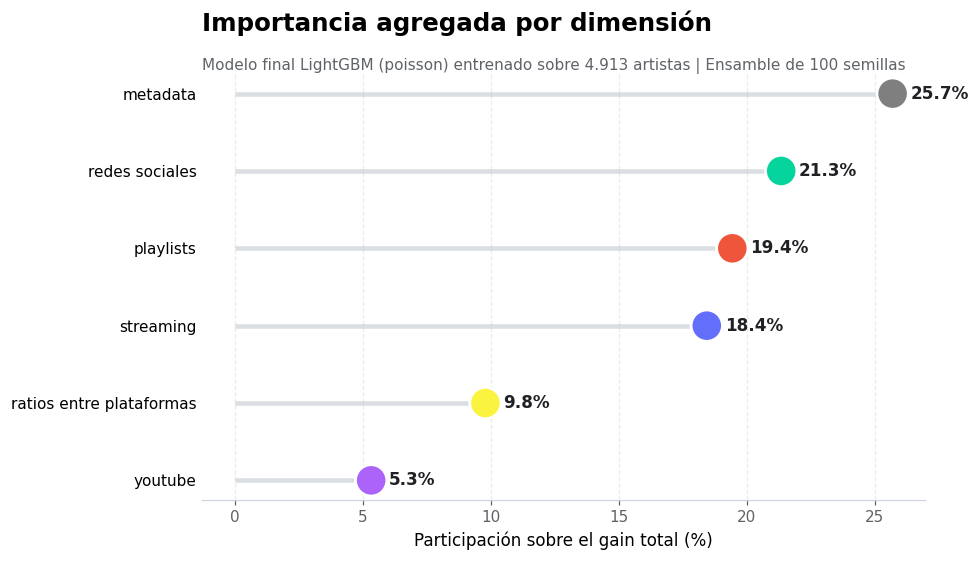

Guardado en: graficos_lgbm-poisson\lgbm-poisson_lollipop_importancia_dimension.png


In [37]:
# ============================================================
# Lollipop de importancia agregada por dimensión
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

df_plot_dimension = (
    tabla_importancias_dimension
    .sort_values("gain_pct", ascending=True)
    .copy()
)

df_plot_dimension["gain_pct_100"] = df_plot_dimension["gain_pct"] * 100

# palette_dimension = {
#     "redes sociales": "#BD164F",
#     "playlists": "#1567A3",
#     "streaming": "#0C3E63",
#     "metadata": "#7D0E34",
#     "ratios entre plataformas": "#F4A261",
#     "youtube": "#2A9D8F",
# }

palette_dimension = {
    "streaming": "#636EFA",
    "playlists": "#EF553B",
    "redes sociales": "#06D49D",
    "youtube": "#AB63FA",
    "metadata": "#7F7F7F",
    "ratios entre plataformas": "#FAF440",
}

colors_dimension = [
    palette_dimension.get(dim, "#333333")
    for dim in df_plot_dimension["dimension"]
]

fig, ax = plt.subplots(figsize=(9, 5.2))

ax.hlines(
    y=df_plot_dimension["dimension"],
    xmin=0,
    xmax=df_plot_dimension["gain_pct_100"],
    linewidth=3,
    alpha=0.35,
    color="#9AA6B2"
)

ax.scatter(
    df_plot_dimension["gain_pct_100"],
    df_plot_dimension["dimension"],
    s=420,
    color=colors_dimension,
    edgecolor="white",
    linewidth=1.8,
    zorder=3
)

for y, valor in zip(df_plot_dimension["dimension"], df_plot_dimension["gain_pct_100"]):
    ax.text(
        valor + 0.7,
        y,
        f"{valor:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#202124"
    )

ax.set_title(
    "Importancia agregada por dimensión",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28
)

ax.set_xlabel("Participación sobre el gain total (%)", fontsize=11)
ax.set_ylabel("")


ax.text(
    0,
    1.01,
    "Modelo final LightGBM (poisson) entrenado sobre 4.913 artistas | Ensamble de 100 semillas",
    transform=ax.transAxes,
    fontsize=10,
    color="#5F6368"
)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#D0D5DD")
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors="#5F6368")

plt.tight_layout()

ruta_dimension = graficos_dir / f"{PARAM['experimento']}_lollipop_importancia_dimension.png"
plt.savefig(ruta_dimension, dpi=300, bbox_inches="tight")
plt.show()

print(f"Guardado en: {ruta_dimension}")

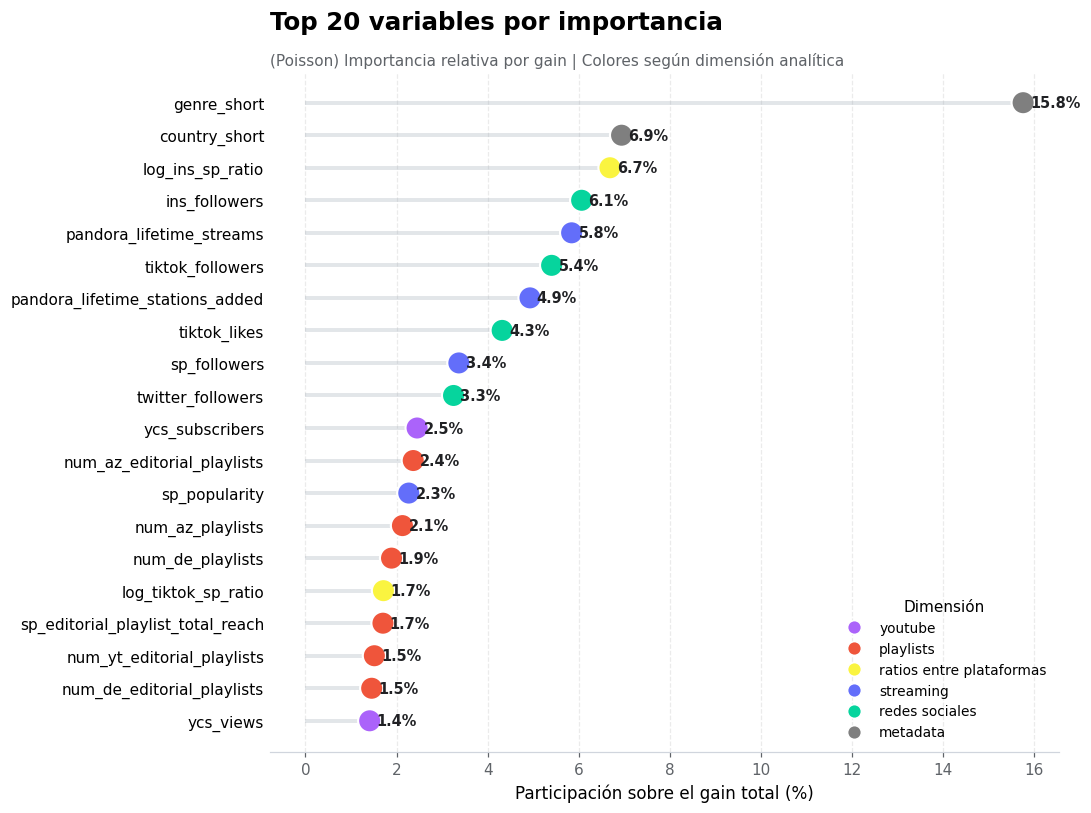

Guardado en: graficos_lgbm-poisson\lgbm-poisson_lollipop_top_20_variables.png


In [38]:
# ============================================================
# Lollipop de top variables por gain
# ============================================================

top_n = 20

df_plot_top = (
    tabla_importancias_full
    .head(top_n)
    .sort_values("gain_pct", ascending=True)
    .copy()
)

df_plot_top["gain_pct_100"] = df_plot_top["gain_pct"] * 100

# palette_dimension = {
#     "redes sociales": "#BD164F",
#     "playlists": "#1567A3",
#     "streaming": "#0C3E63",
#     "metadata": "#7D0E34",
#     "ratios entre plataformas": "#F4A261",
#     "youtube": "#2A9D8F",
# }

palette_dimension = {
    "streaming": "#636EFA",
    "playlists": "#EF553B",
    "redes sociales": "#06D49D",
    "youtube": "#AB63FA",
    "metadata": "#7F7F7F",
    "ratios entre plataformas": "#FAF440",
}

colors_top = [
    palette_dimension.get(dim, "#333333")
    for dim in df_plot_top["dimension"]
]

fig, ax = plt.subplots(figsize=(10, 7.5))

ax.hlines(
    y=df_plot_top["variable"],
    xmin=0,
    xmax=df_plot_top["gain_pct_100"],
    linewidth=2.6,
    alpha=0.28,
    color="#9AA6B2"
)

ax.scatter(
    df_plot_top["gain_pct_100"],
    df_plot_top["variable"],
    s=230,
    color=colors_top,
    edgecolor="white",
    linewidth=1.4,
    zorder=3
)

for y, valor in zip(df_plot_top["variable"], df_plot_top["gain_pct_100"]):
    ax.text(
        valor + 0.15,
        y,
        f"{valor:.1f}%",
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight="bold",
        color="#202124"
    )

ax.set_title(
    f"Top {top_n} variables por importancia",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28
)

ax.text(
    0,
    1.01,
    "(Poisson) Importancia relativa por gain | Colores según dimensión analítica",
    transform=ax.transAxes,
    fontsize=10,
    color="#5F6368"
)

ax.set_xlabel("Participación sobre el gain total (%)", fontsize=11)
ax.set_ylabel("")

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#D0D5DD")
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors="#5F6368")

# Leyenda manual ordenada según presencia en el top
dimensiones_presentes = df_plot_top["dimension"].drop_duplicates().tolist()

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=dim,
        markerfacecolor=palette_dimension.get(dim, "#333333"),
        markeredgecolor="white",
        markersize=9
    )
    for dim in dimensiones_presentes
]

ax.legend(
    handles=handles,
    title="Dimensión",
    frameon=False,
    loc="lower right",
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()

ruta_top = graficos_dir / f"{PARAM['experimento']}_lollipop_top_{top_n}_variables.png"
plt.savefig(ruta_top, dpi=300, bbox_inches="tight")
plt.show()

print(f"Guardado en: {ruta_top}")

# DIAGNOSTICO 
Relación con el target: qué puede decir el modelo

Predicho vs observado en holdout, en escala log.

Distribución de residuos.

Error por niveles de actividad live: ceros, baja, media, alta.

Cobertura de predicción si guardamos las predicciones de cada corrida/semilla: ver si el ensamble es estable por artista.

## predicho vs observado

In [39]:
# ============================================================
# Diagnóstico de predicción sobre holdout
# Variante para Poisson o Tweedie sobre target crudo
# Grupos definidos con la misma lógica de estratificación
# ============================================================

objetivo_modelo = PARAM["train_final"]["param_mejores"].get(
    "objective",
    "sin_objetivo"
)

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

assert np.all(y_holdout >= 0), "y_holdout contiene valores negativos."

assert np.nanmax(y_holdout) > 10, (
    "y_holdout parece estar en escala log o demasiado comprimida. "
    "Para Poisson/Tweedie debería estar en escala original de shows."
)

# Predicción promedio final en escala original.
# Si ya existe y_pred_mean_original desde la evaluación externa, se reutiliza.
# Si no existe, se reconstruye desde apo_preds_holdout.

if "y_pred_mean_original" not in globals():
    y_pred_mean_original = np.maximum(
        apo_preds_holdout.mean(axis=0),
        0
    )

y_pred_mean_original = np.maximum(
    y_pred_mean_original,
    0
)

df_pred_holdout = pd.DataFrame({
    "y_obs_original": y_holdout,
    "y_pred_original": y_pred_mean_original
})

df_pred_holdout["y_obs_log"] = np.log1p(
    df_pred_holdout["y_obs_original"]
)

df_pred_holdout["y_pred_log"] = np.log1p(
    df_pred_holdout["y_pred_original"]
)

# Residuo con convención observada menos predicha.
# Valor positivo: el modelo subpredice.
# Valor negativo: el modelo sobrepredice.

df_pred_holdout["residuo_log"] = (
    df_pred_holdout["y_obs_log"] -
    df_pred_holdout["y_pred_log"]
)

df_pred_holdout["residuo_original"] = (
    df_pred_holdout["y_obs_original"] -
    df_pred_holdout["y_pred_original"]
)

df_pred_holdout["error_abs_log"] = (
    df_pred_holdout["residuo_log"].abs()
)

df_pred_holdout["error_abs_original"] = (
    df_pred_holdout["residuo_original"].abs()
)

# Variable complementaria con convención predicha menos observada.
# Valor positivo: sobrepredicción.
# Valor negativo: subpredicción.

df_pred_holdout["error_log_pred_menos_obs"] = (
    df_pred_holdout["y_pred_log"] -
    df_pred_holdout["y_obs_log"]
)

df_pred_holdout["error_original_pred_menos_obs"] = (
    df_pred_holdout["y_pred_original"] -
    df_pred_holdout["y_obs_original"]
)

# Cortes por cuantiles definidos sobre todo el target disponible.
# Se usa log1p(y_all), igual que en la estrategia de estratificación.

_, bins_target_log = pd.qcut(
    pd.Series(np.log1p(y_all)),
    q=5,
    retbins=True,
    duplicates="drop"
)

# Se amplían extremos para asegurar que todo holdout entre en algún grupo.

bins_target_log[0] = -np.inf
bins_target_log[-1] = np.inf

n_grupos_target = len(bins_target_log) - 1

labels_grupos_target = [
    f"Q{i + 1}" for i in range(n_grupos_target)
]

df_pred_holdout["grupo_target_log"] = pd.cut(
    df_pred_holdout["y_obs_log"],
    bins=bins_target_log,
    labels=labels_grupos_target,
    include_lowest=True
)

print("Distribución del dataframe diagnóstico:")
display(df_pred_holdout.describe())

print("\nCantidad de artistas por grupo de target:")
display(
    df_pred_holdout["grupo_target_log"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(
        columns={
            "grupo_target_log": "grupo_target_log",
            "count": "n_artistas"
        }
    )
)

print("\nPrimeras filas del diagnóstico:")
display(df_pred_holdout.head())

ruta_df_pred_holdout = (
    f"{PARAM['experimento']}_{objetivo_modelo}_diagnostico_pred_holdout.csv"
)

df_pred_holdout.to_csv(
    ruta_df_pred_holdout,
    index=False
)

print(f"\nDiagnóstico guardado en: {ruta_df_pred_holdout}")

Distribución del dataframe diagnóstico:


,y_obs_original,y_pred_original,y_obs_log,y_pred_log,residuo_log,residuo_original,error_abs_log,error_abs_original,error_log_pred_menos_obs,error_original_pred_menos_obs
count,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000
mean,24.558345,23.845328,2.322284,2.992967,-0.670684,0.713016,1.124339,17.523901,0.670684,-0.713016
std,30.009949,16.604328,1.547527,0.691765,1.300888,24.781340,0.936714,17.530773,1.300888,24.781340
min,0.000000,1.310817,0.000000,0.837601,-4.082302,-58.281768,0.001452,0.029062,-2.527080,-150.187763
25%,1.000000,11.893567,0.693147,2.556727,-1.618894,-12.988984,0.365906,5.897593,-0.349031,-9.946903
50%,12.000000,20.125238,2.564949,3.050467,-0.380756,-4.372783,0.844819,12.241601,0.380756,4.372783
75%,39.000000,31.423669,3.688879,3.478888,0.349031,9.946903,1.684836,23.210162,1.618894,12.988984
max,179.000000,112.425563,5.192957,4.731147,2.527080,150.187763,4.082302,150.187763,4.082302,58.281768



Cantidad de artistas por grupo de target:


,grupo_target_log,n_artistas
0,Q1,378
1,Q2,225
2,Q3,293
3,Q4,290
4,Q5,288



Primeras filas del diagnóstico:


,y_obs_original,y_pred_original,y_obs_log,y_pred_log,residuo_log,residuo_original,error_abs_log,error_abs_original,error_log_pred_menos_obs,error_original_pred_menos_obs,grupo_target_log
0,13.0,37.376840,2.639057,3.647454,-1.008397,-24.376840,1.008397,24.376840,1.008397,24.376840,Q3
1,1.0,18.910910,0.693147,2.991268,-2.298121,-17.910910,2.298121,17.910910,2.298121,17.910910,Q1
2,16.0,25.638002,2.833213,3.282339,-0.449126,-9.638002,0.449126,9.638002,0.449126,9.638002,Q3
3,0.0,6.783102,0.000000,2.051955,-2.051955,-6.783102,2.051955,6.783102,2.051955,6.783102,Q1
4,87.0,51.898790,4.477337,3.968380,0.508956,35.101210,0.508956,35.101210,-0.508956,-35.101210,Q5



Diagnóstico guardado en: lgbm-poisson_poisson_diagnostico_pred_holdout.csv


In [40]:
# ============================================================
# Error por grupos del target definidos por cuantiles
# Variante para Poisson o Tweedie sobre target crudo
# ============================================================

objetivo_modelo = PARAM["train_final"]["param_mejores"].get(
    "objective",
    "sin_objetivo"
)

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

columnas_necesarias_error_grupo = [
    "grupo_target_log",
    "y_obs_log",
    "y_pred_log",
    "residuo_log",
    "error_abs_log",
    "y_obs_original",
    "y_pred_original",
    "error_abs_original"
]

columnas_faltantes_error_grupo = [
    columna for columna in columnas_necesarias_error_grupo
    if columna not in df_pred_holdout.columns
]

assert len(columnas_faltantes_error_grupo) == 0, (
    "Faltan columnas en df_pred_holdout: "
    f"{columnas_faltantes_error_grupo}"
)

tabla_error_por_grupo_target = (
    df_pred_holdout
    .groupby("grupo_target_log", observed=True)
    .agg(
        n_artistas=("y_obs_log", "size"),
        y_obs_log_media=("y_obs_log", "mean"),
        y_obs_log_mediana=("y_obs_log", "median"),
        y_pred_log_media=("y_pred_log", "mean"),
        y_pred_log_mediana=("y_pred_log", "median"),
        residuo_log_medio=("residuo_log", "mean"),
        residuo_log_mediano=("residuo_log", "median"),
        mae_log=("error_abs_log", "mean"),
        rmse_log=("residuo_log", lambda x: float(np.sqrt(np.mean(x ** 2)))),
        shows_obs_mediana=("y_obs_original", "median"),
        shows_pred_mediana=("y_pred_original", "median"),
        shows_obs_media=("y_obs_original", "mean"),
        shows_pred_media=("y_pred_original", "mean"),
        mae_original=("error_abs_original", "mean"),
        rmse_original=("residuo_original", lambda x: float(np.sqrt(np.mean(x ** 2))))
    )
    .reset_index()
)

tabla_error_por_grupo_target["brecha_mediana_log_pred_menos_obs"] = (
    tabla_error_por_grupo_target["y_pred_log_mediana"] -
    tabla_error_por_grupo_target["y_obs_log_mediana"]
)

tabla_error_por_grupo_target["brecha_mediana_original_pred_menos_obs"] = (
    tabla_error_por_grupo_target["shows_pred_mediana"] -
    tabla_error_por_grupo_target["shows_obs_mediana"]
)

tabla_error_por_grupo_target["sesgo_interpretacion"] = np.where(
    tabla_error_por_grupo_target["residuo_log_medio"] > 0,
    "subpredice",
    np.where(
        tabla_error_por_grupo_target["residuo_log_medio"] < 0,
        "sobrepredice",
        "sin sesgo medio"
    )
)

display(tabla_error_por_grupo_target)

ruta_error_por_grupo_target = (
    f"{PARAM['experimento']}_{objetivo_modelo}_error_por_quintil_target_holdout.csv"
)

tabla_error_por_grupo_target.to_csv(
    ruta_error_por_grupo_target,
    index=False
)

print(f"Tabla de error por quintil guardada en: {ruta_error_por_grupo_target}")

,grupo_target_log,n_artistas,y_obs_log_media,y_obs_log_mediana,y_pred_log_media,y_pred_log_mediana,residuo_log_medio,residuo_log_mediano,mae_log,rmse_log,shows_obs_mediana,shows_pred_mediana,shows_obs_media,shows_pred_media,mae_original,rmse_original,brecha_mediana_log_pred_menos_obs,brecha_mediana_original_pred_menos_obs,sesgo_interpretacion
0,Q1,378,0.221880,0.000000,2.525904,2.558924,-2.304023,-2.249357,2.304023,2.432154,0.0,11.921973,0.320106,15.078521,14.758415,18.804348,2.558924,11.921973,sobrepredice
1,Q2,225,1.442821,1.386294,2.797607,2.818280,-1.354787,-1.314569,1.365936,1.496427,3.0,15.748023,3.457778,18.187024,14.791580,18.230657,1.431986,12.748023,sobrepredice
2,Q3,293,2.587131,2.639057,2.887152,2.895579,-0.300021,-0.300644,0.494109,0.618647,13.0,17.093975,12.979522,19.310888,8.797287,12.334651,0.256522,4.093975,sobrepredice
3,Q4,290,3.511299,3.496508,3.259965,3.266397,0.251334,0.211918,0.428627,0.540775,32.0,25.216745,33.279310,27.861364,12.300538,15.142588,-0.230111,-6.783255,subpredice
4,Q5,288,4.299425,4.283563,3.597413,3.635925,0.702012,0.643336,0.728972,0.872027,71.5,36.936972,75.854167,40.341552,37.425980,45.101105,-0.647638,-34.563028,subpredice


Tabla de error por quintil guardada en: lgbm-poisson_poisson_error_por_quintil_target_holdout.csv


In [41]:
# ============================================================
# Diagnóstico de predicción sobre holdout
# Variante para Poisson o Tweedie sobre target crudo
# ============================================================

objetivo_modelo = PARAM["train_final"]["param_mejores"].get(
    "objective",
    "sin_objetivo"
)

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

assert np.all(y_holdout >= 0), "y_holdout contiene valores negativos."

assert np.nanmax(y_holdout) > 10, (
    "y_holdout parece estar en escala log o demasiado comprimida. "
    "Para Poisson/Tweedie debería estar en escala original de shows."
)

# Predicción promedio final en escala original.
# Si ya existe y_pred_mean_original desde la evaluación externa, se reutiliza.
# Si no existe, se reconstruye desde apo_preds_holdout.

if "y_pred_mean_original" not in globals():
    y_pred_mean_original = np.maximum(
        apo_preds_holdout.mean(axis=0),
        0
    )

y_pred_mean_original = np.maximum(
    y_pred_mean_original,
    0
)

df_pred_holdout = pd.DataFrame({
    "y_obs_original": y_holdout,
    "y_pred_original": y_pred_mean_original
})

df_pred_holdout["y_obs_log"] = np.log1p(
    df_pred_holdout["y_obs_original"]
)

df_pred_holdout["y_pred_log"] = np.log1p(
    df_pred_holdout["y_pred_original"]
)

df_pred_holdout["residuo_log"] = (
    df_pred_holdout["y_obs_log"] -
    df_pred_holdout["y_pred_log"]
)

df_pred_holdout["residuo_original"] = (
    df_pred_holdout["y_obs_original"] -
    df_pred_holdout["y_pred_original"]
)

df_pred_holdout["error_abs_log"] = (
    df_pred_holdout["residuo_log"].abs()
)

df_pred_holdout["error_abs_original"] = (
    df_pred_holdout["residuo_original"].abs()
)

df_pred_holdout["error_log_pred_menos_obs"] = (
    df_pred_holdout["y_pred_log"] -
    df_pred_holdout["y_obs_log"]
)

df_pred_holdout["error_original_pred_menos_obs"] = (
    df_pred_holdout["y_pred_original"] -
    df_pred_holdout["y_obs_original"]
)

# Cortes por cuantiles definidos sobre todo el target disponible.
# Se usa log1p(y_all), igual que en la estrategia de estratificación.

_, bins_target_log = pd.qcut(
    pd.Series(np.log1p(y_all)),
    q=5,
    retbins=True,
    duplicates="drop"
)

bins_target_log[0] = -np.inf
bins_target_log[-1] = np.inf

labels_grupos_target = [
    f"Q{i + 1}" for i in range(len(bins_target_log) - 1)
]

df_pred_holdout["grupo_target_log"] = pd.cut(
    df_pred_holdout["y_obs_log"],
    bins=bins_target_log,
    labels=labels_grupos_target,
    include_lowest=True
)

tabla_error_por_quintil = (
    df_pred_holdout
    .groupby("grupo_target_log", observed=True)
    .agg(
        n_artistas=("y_obs_log", "size"),
        n_cero_shows=("y_obs_original", lambda x: int((x == 0).sum())),
        shows_obs_mediana=("y_obs_original", "median"),
        shows_pred_mediana=("y_pred_original", "median"),
        shows_obs_media=("y_obs_original", "mean"),
        shows_pred_media=("y_pred_original", "mean"),
        y_obs_log_media=("y_obs_log", "mean"),
        y_pred_log_media=("y_pred_log", "mean"),
        y_obs_log_mediana=("y_obs_log", "median"),
        y_pred_log_mediana=("y_pred_log", "median"),
        residuo_log_medio=("residuo_log", "mean"),
        residuo_log_mediano=("residuo_log", "median"),
        mae_log=("error_abs_log", "mean"),
        rmse_log=("residuo_log", lambda x: float(np.sqrt(np.mean(x ** 2)))),
        mae_original=("error_abs_original", "mean"),
        rmse_original=("residuo_original", lambda x: float(np.sqrt(np.mean(x ** 2))))
    )
    .reset_index()
)

tabla_error_por_quintil["pct_cero_shows"] = (
    tabla_error_por_quintil["n_cero_shows"] /
    tabla_error_por_quintil["n_artistas"] *
    100
)

tabla_error_por_quintil["brecha_mediana_original_pred_menos_obs"] = (
    tabla_error_por_quintil["shows_pred_mediana"] -
    tabla_error_por_quintil["shows_obs_mediana"]
)

tabla_error_por_quintil["brecha_mediana_log_pred_menos_obs"] = (
    tabla_error_por_quintil["y_pred_log_mediana"] -
    tabla_error_por_quintil["y_obs_log_mediana"]
)

tabla_error_por_quintil["sesgo_interpretacion"] = np.where(
    tabla_error_por_quintil["residuo_log_medio"] > 0,
    "subpredice",
    np.where(
        tabla_error_por_quintil["residuo_log_medio"] < 0,
        "sobrepredice",
        "sin sesgo medio"
    )
)

display(tabla_error_por_quintil)

ruta_error_por_quintil = (
    f"{PARAM['experimento']}_{objetivo_modelo}_error_por_quintil_target_holdout.csv"
)

tabla_error_por_quintil.to_csv(
    ruta_error_por_quintil,
    index=False
)

print(f"Tabla de error por quintil guardada en: {ruta_error_por_quintil}")

,grupo_target_log,n_artistas,n_cero_shows,shows_obs_mediana,shows_pred_mediana,shows_obs_media,shows_pred_media,y_obs_log_media,y_pred_log_media,y_obs_log_mediana,...,residuo_log_medio,residuo_log_mediano,mae_log,rmse_log,mae_original,rmse_original,pct_cero_shows,brecha_mediana_original_pred_menos_obs,brecha_mediana_log_pred_menos_obs,sesgo_interpretacion
0,Q1,378,257,0.0,11.921973,0.320106,15.078521,0.221880,2.525904,0.000000,...,-2.304023,-2.249357,2.304023,2.432154,14.758415,18.804348,67.989418,11.921973,2.558924,sobrepredice
1,Q2,225,0,3.0,15.748023,3.457778,18.187024,1.442821,2.797607,1.386294,...,-1.354787,-1.314569,1.365936,1.496427,14.791580,18.230657,0.000000,12.748023,1.431986,sobrepredice
2,Q3,293,0,13.0,17.093975,12.979522,19.310888,2.587131,2.887152,2.639057,...,-0.300021,-0.300644,0.494109,0.618647,8.797287,12.334651,0.000000,4.093975,0.256522,sobrepredice
3,Q4,290,0,32.0,25.216745,33.279310,27.861364,3.511299,3.259965,3.496508,...,0.251334,0.211918,0.428627,0.540775,12.300538,15.142588,0.000000,-6.783255,-0.230111,subpredice
4,Q5,288,0,71.5,36.936972,75.854167,40.341552,4.299425,3.597413,4.283563,...,0.702012,0.643336,0.728972,0.872027,37.425980,45.101105,0.000000,-34.563028,-0.647638,subpredice


Tabla de error por quintil guardada en: lgbm-poisson_poisson_error_por_quintil_target_holdout.csv


## grafico obs s predicho original

Gráficos guardados en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos_lgbm-poisson


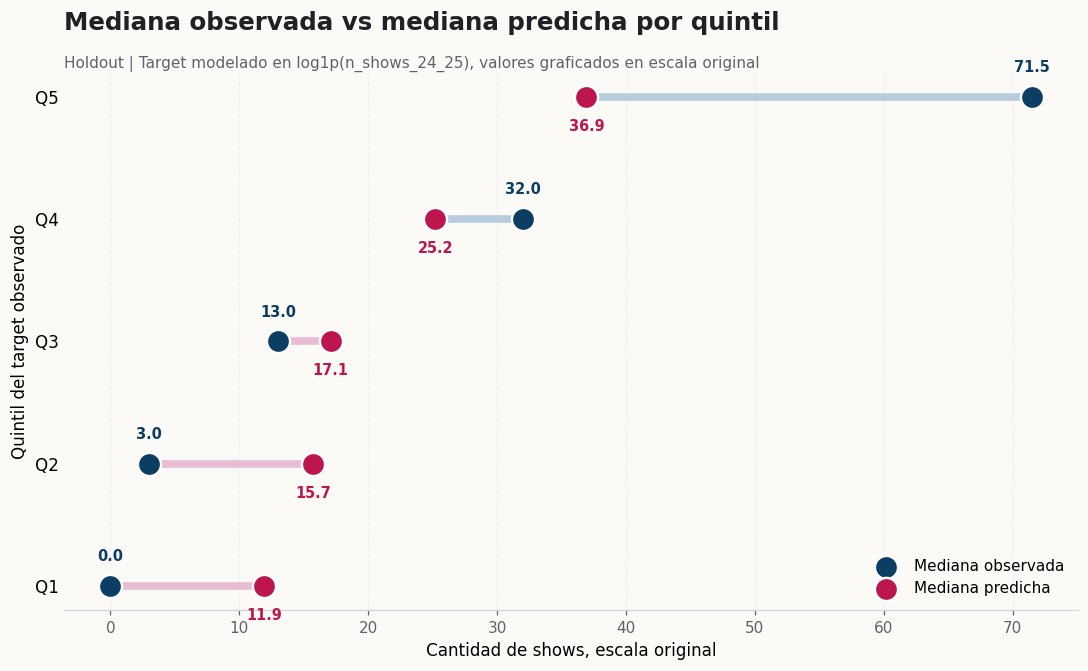

Guardado en: graficos_lgbm-poisson\lgbm-poisson_mediana_observada_vs_predicha_por_quintil.png


In [42]:
# ============================================================
# Mediana observada vs mediana predicha por quintil del target
# ============================================================

import pathlib
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Directorio de guardado
# ------------------------------------------------------------

if "graficos_dir" not in globals():
    graficos_dir = pathlib.Path(f"graficos_{PARAM['experimento']}")
    graficos_dir.mkdir(exist_ok=True)

print(f"Gráficos guardados en: {graficos_dir.resolve()}")

# ------------------------------------------------------------
# Preparación de datos
# ------------------------------------------------------------

df_plot_medianas_quintil = tabla_error_por_quintil.copy()

df_plot_medianas_quintil["brecha_mediana"] = (
    df_plot_medianas_quintil["shows_pred_mediana"] -
    df_plot_medianas_quintil["shows_obs_mediana"]
)

df_plot_medianas_quintil["direccion_sesgo"] = np.where(
    df_plot_medianas_quintil["brecha_mediana"] > 0,
    "sobrepredicción",
    np.where(
        df_plot_medianas_quintil["brecha_mediana"] < 0,
        "subpredicción",
        "sin brecha"
    )
)

# Orden natural de los quintiles
df_plot_medianas_quintil = df_plot_medianas_quintil.sort_values(
    "grupo_target_log"
).reset_index(drop=True)

posiciones_y = np.arange(len(df_plot_medianas_quintil))

# ------------------------------------------------------------
# Paleta
# ------------------------------------------------------------

color_observado = "#0C3E63"
color_predicho = "#BD164F"
color_linea_sobre = "#D989B5"
color_linea_sub = "#7FA7C7"
color_texto = "#202124"
color_grilla = "#D0D5DD"
color_fondo = "#FBFAF7"

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6.2))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

for i, fila in df_plot_medianas_quintil.iterrows():
    
    x_obs = fila["shows_obs_mediana"]
    x_pred = fila["shows_pred_mediana"]
    
    color_linea = (
        color_linea_sobre
        if fila["brecha_mediana"] > 0
        else color_linea_sub
    )
    
    ax.plot(
        [x_obs, x_pred],
        [posiciones_y[i], posiciones_y[i]],
        color=color_linea,
        linewidth=5,
        alpha=0.55,
        solid_capstyle="round",
        zorder=1
    )
    
    ax.scatter(
        x_obs,
        posiciones_y[i],
        s=230,
        color=color_observado,
        edgecolor="white",
        linewidth=1.6,
        zorder=3,
        label="Mediana observada" if i == 0 else None
    )
    
    ax.scatter(
        x_pred,
        posiciones_y[i],
        s=230,
        color=color_predicho,
        edgecolor="white",
        linewidth=1.6,
        zorder=3,
        label="Mediana predicha" if i == 0 else None
    )
    
    ax.text(
        x_obs,
        posiciones_y[i] + 0.18,
        f"{x_obs:.1f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        color=color_observado,
        fontweight="bold"
    )
    
    ax.text(
        x_pred,
        posiciones_y[i] - 0.18,
        f"{x_pred:.1f}",
        ha="center",
        va="top",
        fontsize=9.5,
        color=color_predicho,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Detalles visuales
# ------------------------------------------------------------

ax.set_yticks(posiciones_y)
ax.set_yticklabels(df_plot_medianas_quintil["grupo_target_log"], fontsize=11)

ax.set_xlabel("Cantidad de shows, escala original", fontsize=11)
ax.set_ylabel("Quintil del target observado", fontsize=11)

ax.set_title(
    "Mediana observada vs mediana predicha por quintil",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28,
    color=color_texto
)

ax.text(
    0,
    1.01,
    "Holdout | Target modelado en log1p(n_shows_24_25), valores graficados en escala original",
    transform=ax.transAxes,
    fontsize=10,
    color="#5F6368"
)

ax.grid(axis="x", linestyle="--", alpha=0.28, color=color_grilla)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(color_grilla)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors="#5F6368")

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

ruta_grafico_medianas_quintil = (
    graficos_dir /
    f"{PARAM['experimento']}_mediana_observada_vs_predicha_por_quintil.png"
)

plt.savefig(
    ruta_grafico_medianas_quintil,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Guardado en: {ruta_grafico_medianas_quintil}")

## grafico obs vs predichos log

In [43]:
# ============================================================
# Mediana observada vs mediana predicha por quintil
# Escala log1p(n_shows_24_25)
# Variante para Poisson o Tweedie sobre target crudo
# ============================================================

objetivo_modelo = PARAM["train_final"]["param_mejores"].get(
    "objective",
    "sin_objetivo"
)

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

columnas_necesarias_medianas = [
    "grupo_target_log",
    "y_obs_log",
    "y_pred_log",
    "y_obs_original",
    "y_pred_original"
]

columnas_faltantes_medianas = [
    columna for columna in columnas_necesarias_medianas
    if columna not in df_pred_holdout.columns
]

assert len(columnas_faltantes_medianas) == 0, (
    "Faltan columnas en df_pred_holdout: "
    f"{columnas_faltantes_medianas}"
)

if "graficos_dir" not in globals():
    graficos_dir = pathlib.Path(f"graficos_{PARAM['experimento']}_{objetivo_modelo}")
    graficos_dir.mkdir(exist_ok=True)

print(f"Gráficos guardados en: {graficos_dir.resolve()}")

# ------------------------------------------------------------
# Preparación de datos en escala log
# ------------------------------------------------------------

df_plot_medianas_log_quintil = (
    df_pred_holdout
    .groupby("grupo_target_log", observed=True)
    .agg(
        n_artistas=("y_obs_log", "size"),
        y_obs_log_mediana=("y_obs_log", "median"),
        y_pred_log_mediana=("y_pred_log", "median"),
        shows_obs_mediana=("y_obs_original", "median"),
        shows_pred_mediana=("y_pred_original", "median")
    )
    .reset_index()
)

df_plot_medianas_log_quintil["brecha_log_mediana"] = (
    df_plot_medianas_log_quintil["y_pred_log_mediana"] -
    df_plot_medianas_log_quintil["y_obs_log_mediana"]
)

df_plot_medianas_log_quintil["brecha_original_mediana"] = (
    df_plot_medianas_log_quintil["shows_pred_mediana"] -
    df_plot_medianas_log_quintil["shows_obs_mediana"]
)

df_plot_medianas_log_quintil["direccion_sesgo"] = np.where(
    df_plot_medianas_log_quintil["brecha_log_mediana"] > 0,
    "sobrepredicción",
    np.where(
        df_plot_medianas_log_quintil["brecha_log_mediana"] < 0,
        "subpredicción",
        "sin brecha"
    )
)

df_plot_medianas_log_quintil["orden_quintil"] = (
    df_plot_medianas_log_quintil["grupo_target_log"]
    .astype(str)
    .str.replace("Q", "", regex=False)
    .astype(int)
)

df_plot_medianas_log_quintil = (
    df_plot_medianas_log_quintil
    .sort_values("orden_quintil")
    .reset_index(drop=True)
)

posiciones_y = np.arange(len(df_plot_medianas_log_quintil))

display(df_plot_medianas_log_quintil)

Gráficos guardados en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos_lgbm-poisson


,grupo_target_log,n_artistas,y_obs_log_mediana,y_pred_log_mediana,shows_obs_mediana,shows_pred_mediana,brecha_log_mediana,brecha_original_mediana,direccion_sesgo,orden_quintil
0,Q1,378,0.000000,2.558924,0.0,11.921973,2.558924,11.921973,sobrepredicción,1
1,Q2,225,1.386294,2.818280,3.0,15.748023,1.431986,12.748023,sobrepredicción,2
2,Q3,293,2.639057,2.895579,13.0,17.093975,0.256522,4.093975,sobrepredicción,3
3,Q4,290,3.496508,3.266397,32.0,25.216745,-0.230111,-6.783255,subpredicción,4
4,Q5,288,4.283563,3.635925,71.5,36.936972,-0.647638,-34.563028,subpredicción,5


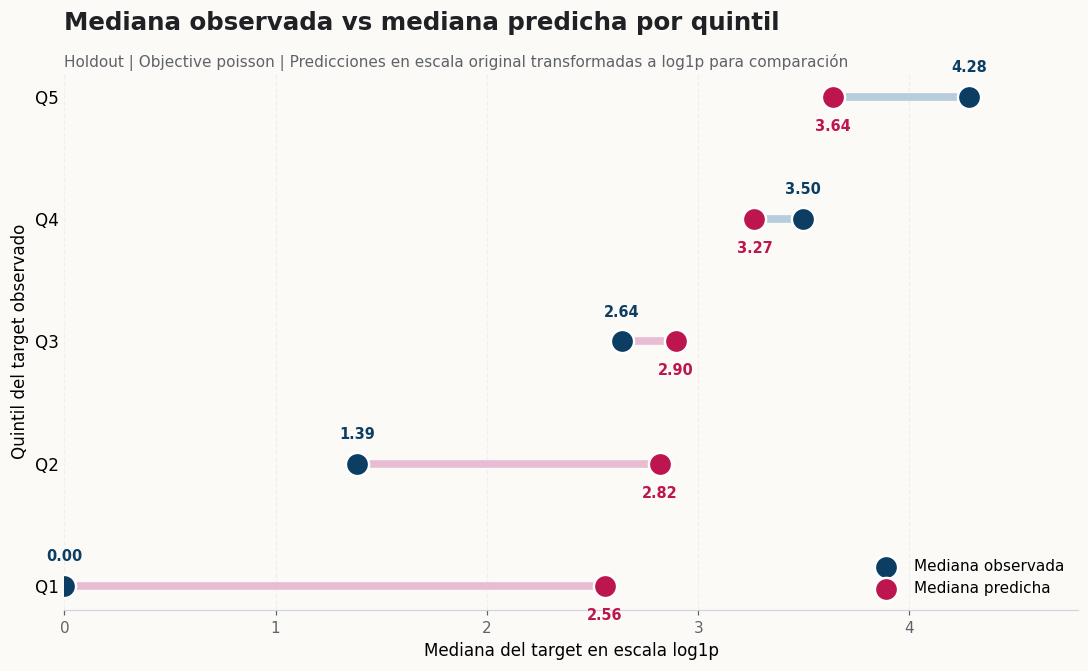

Guardado en: graficos_lgbm-poisson\lgbm-poisson_poisson_mediana_observada_vs_predicha_por_quintil_log.png


In [44]:
# ============================================================
# Dumbbell plot en escala log1p
# Variante para Poisson o Tweedie sobre target crudo
# ============================================================

objetivo_modelo = PARAM["train_final"]["param_mejores"].get(
    "objective",
    "sin_objetivo"
)

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

columnas_necesarias_dumbbell = [
    "grupo_target_log",
    "y_obs_log_mediana",
    "y_pred_log_mediana",
    "brecha_log_mediana"
]

columnas_faltantes_dumbbell = [
    columna for columna in columnas_necesarias_dumbbell
    if columna not in df_plot_medianas_log_quintil.columns
]

assert len(columnas_faltantes_dumbbell) == 0, (
    "Faltan columnas en df_plot_medianas_log_quintil: "
    f"{columnas_faltantes_dumbbell}"
)

if "graficos_dir" not in globals():
    graficos_dir = pathlib.Path(f"graficos_{PARAM['experimento']}_{objetivo_modelo}")
    graficos_dir.mkdir(exist_ok=True)

color_observado = "#0C3E63"
color_predicho = "#BD164F"
color_linea_sobre = "#D989B5"
color_linea_sub = "#7FA7C7"
color_texto = "#202124"
color_secundario = "#5F6368"
color_grilla = "#D0D5DD"
color_fondo = "#FBFAF7"

fig, ax = plt.subplots(figsize=(10, 6.2))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

for i, fila in df_plot_medianas_log_quintil.iterrows():
    
    x_obs = fila["y_obs_log_mediana"]
    x_pred = fila["y_pred_log_mediana"]
    
    color_linea = (
        color_linea_sobre
        if fila["brecha_log_mediana"] > 0
        else color_linea_sub
    )
    
    ax.plot(
        [x_obs, x_pred],
        [posiciones_y[i], posiciones_y[i]],
        color=color_linea,
        linewidth=5,
        alpha=0.55,
        solid_capstyle="round",
        zorder=1
    )
    
    ax.scatter(
        x_obs,
        posiciones_y[i],
        s=230,
        color=color_observado,
        edgecolor="white",
        linewidth=1.6,
        zorder=3,
        label="Mediana observada" if i == 0 else None
    )
    
    ax.scatter(
        x_pred,
        posiciones_y[i],
        s=230,
        color=color_predicho,
        edgecolor="white",
        linewidth=1.6,
        zorder=3,
        label="Mediana predicha" if i == 0 else None
    )
    
    ax.text(
        x_obs,
        posiciones_y[i] + 0.18,
        f"{x_obs:.2f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        color=color_observado,
        fontweight="bold"
    )
    
    ax.text(
        x_pred,
        posiciones_y[i] - 0.18,
        f"{x_pred:.2f}",
        ha="center",
        va="top",
        fontsize=9.5,
        color=color_predicho,
        fontweight="bold"
    )

ax.set_yticks(posiciones_y)

ax.set_yticklabels(
    df_plot_medianas_log_quintil["grupo_target_log"],
    fontsize=11
)

ax.set_xlabel("Mediana del target en escala log1p", fontsize=11)
ax.set_ylabel("Quintil del target observado", fontsize=11)

titulo_grafico = "Mediana observada vs mediana predicha por quintil"

subtitulo_grafico = (
    f"Holdout | Objective {objetivo_modelo} | "
    "Predicciones en escala original transformadas a log1p para comparación"
)

ax.set_title(
    titulo_grafico,
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28,
    color=color_texto
)

ax.text(
    0,
    1.01,
    subtitulo_grafico,
    transform=ax.transAxes,
    fontsize=10,
    color=color_secundario
)

valor_maximo_x = max(
    df_plot_medianas_log_quintil["y_obs_log_mediana"].max(),
    df_plot_medianas_log_quintil["y_pred_log_mediana"].max()
)

ax.set_xlim(
    left=0,
    right=valor_maximo_x * 1.12
)

ax.grid(axis="x", linestyle="--", alpha=0.28, color=color_grilla)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(color_grilla)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors=color_secundario)

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

ruta_grafico_medianas_log_quintil = (
    graficos_dir /
    f"{PARAM['experimento']}_{objetivo_modelo}_mediana_observada_vs_predicha_por_quintil_log.png"
)

plt.savefig(
    ruta_grafico_medianas_log_quintil,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Guardado en: {ruta_grafico_medianas_log_quintil}")

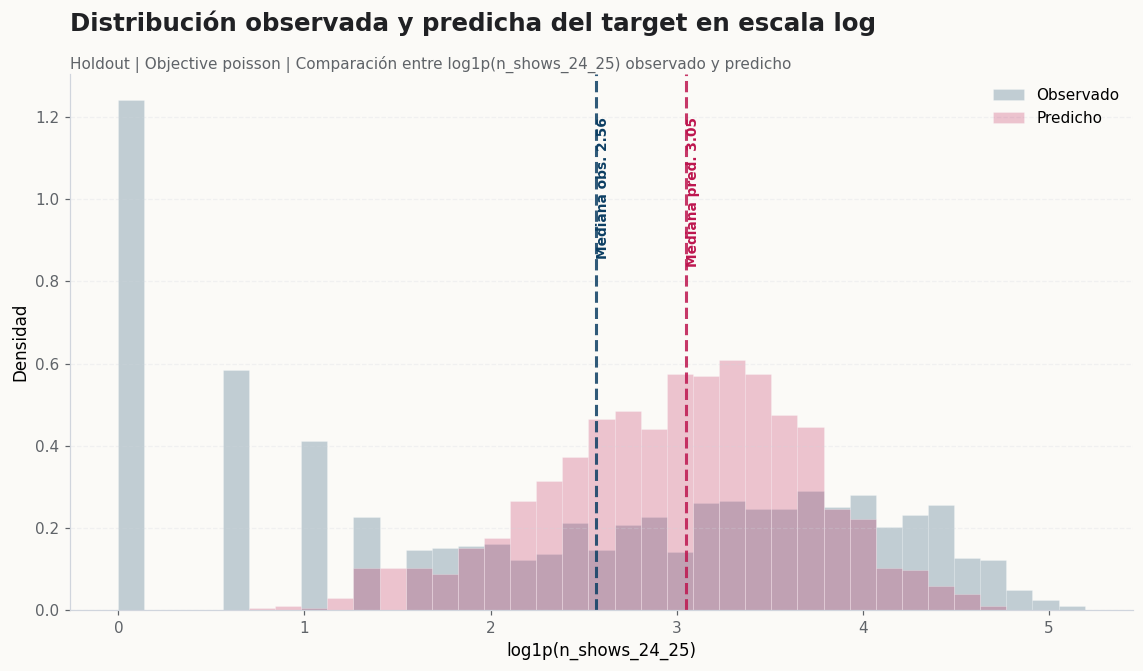

Guardado en: graficos_lgbm-poisson\lgbm-poisson_poisson_distribucion_observada_predicha_log.png


In [45]:
# ============================================================
# Distribución observada y predicha del target en escala log
# Variante para Poisson o Tweedie sobre target crudo
# ============================================================

objetivo_modelo = PARAM["train_final"]["param_mejores"].get(
    "objective",
    "sin_objetivo"
)

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

columnas_necesarias_distribucion = [
    "y_obs_log",
    "y_pred_log",
    "y_obs_original",
    "y_pred_original"
]

columnas_faltantes_distribucion = [
    columna for columna in columnas_necesarias_distribucion
    if columna not in df_pred_holdout.columns
]

assert len(columnas_faltantes_distribucion) == 0, (
    "Faltan columnas en df_pred_holdout: "
    f"{columnas_faltantes_distribucion}"
)

if "graficos_dir" not in globals():
    graficos_dir = pathlib.Path(f"graficos_{PARAM['experimento']}_{objetivo_modelo}")
    graficos_dir.mkdir(exist_ok=True)

color_observado = "#0C3E63"
color_predicho = "#BD164F"
color_texto = "#202124"
color_secundario = "#5F6368"
color_grilla = "#D0D5DD"
color_fondo = "#FBFAF7"

y_obs_log_plot = df_pred_holdout["y_obs_log"].dropna()
y_pred_log_plot = df_pred_holdout["y_pred_log"].dropna()

assert len(y_obs_log_plot) > 0, "No hay valores observados para graficar."
assert len(y_pred_log_plot) > 0, "No hay valores predichos para graficar."

mediana_obs_log = y_obs_log_plot.median()
mediana_pred_log = y_pred_log_plot.median()

bins_log = np.linspace(
    min(y_obs_log_plot.min(), y_pred_log_plot.min()),
    max(y_obs_log_plot.max(), y_pred_log_plot.max()),
    38
)

fig, ax = plt.subplots(figsize=(10.5, 6.2))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

ax.hist(
    y_obs_log_plot,
    bins=bins_log,
    density=True,
    alpha=0.24,
    color=color_observado,
    edgecolor="white",
    linewidth=0.6,
    label="Observado"
)

ax.hist(
    y_pred_log_plot,
    bins=bins_log,
    density=True,
    alpha=0.24,
    color=color_predicho,
    edgecolor="white",
    linewidth=0.6,
    label="Predicho"
)

ax.axvline(
    mediana_obs_log,
    color=color_observado,
    linestyle="--",
    linewidth=2,
    alpha=0.85
)

ax.axvline(
    mediana_pred_log,
    color=color_predicho,
    linestyle="--",
    linewidth=2,
    alpha=0.85
)

altura_texto = ax.get_ylim()[1] * 0.92

ax.text(
    mediana_obs_log,
    altura_texto,
    f"Mediana obs. {mediana_obs_log:.2f}",
    rotation=90,
    va="top",
    ha="left",
    fontsize=9,
    color=color_observado,
    fontweight="bold"
)

ax.text(
    mediana_pred_log,
    altura_texto,
    f"Mediana pred. {mediana_pred_log:.2f}",
    rotation=90,
    va="top",
    ha="left",
    fontsize=9,
    color=color_predicho,
    fontweight="bold"
)

titulo_grafico = "Distribución observada y predicha del target en escala log"

subtitulo_grafico = (
    f"Holdout | Objective {objetivo_modelo} | "
    "Comparación entre log1p(n_shows_24_25) observado y predicho"
)

ax.set_title(
    titulo_grafico,
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28,
    color=color_texto
)

ax.text(
    0,
    1.01,
    subtitulo_grafico,
    transform=ax.transAxes,
    fontsize=10,
    color=color_secundario
)

ax.set_xlabel("log1p(n_shows_24_25)", fontsize=11)
ax.set_ylabel("Densidad", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.25, color=color_grilla)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(color_grilla)
ax.spines["bottom"].set_color(color_grilla)

ax.tick_params(axis="x", colors=color_secundario)
ax.tick_params(axis="y", colors=color_secundario)

ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=10
)

plt.tight_layout()

ruta_distribuciones_log = (
    graficos_dir /
    f"{PARAM['experimento']}_{objetivo_modelo}_distribucion_observada_predicha_log.png"
)

plt.savefig(
    ruta_distribuciones_log,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Guardado en: {ruta_distribuciones_log}")

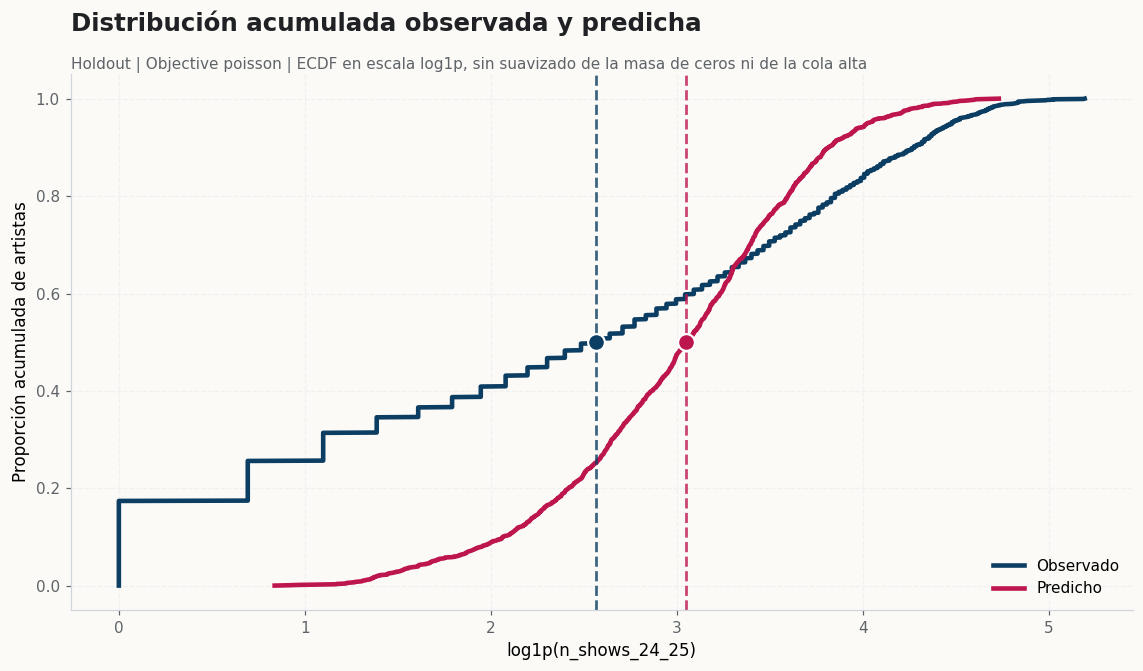

Guardado en: graficos_lgbm-poisson\lgbm-poisson_poisson_ecdf_observada_predicha_log.png


In [46]:
# ============================================================
# ECDF observada y predicha del target en escala log
# Variante para Poisson o Tweedie sobre target crudo
# ============================================================

objetivo_modelo = PARAM["train_final"]["param_mejores"].get(
    "objective",
    "sin_objetivo"
)

assert objetivo_modelo in ["poisson", "tweedie"], (
    f"Este bloque espera objective poisson o tweedie. Objective actual: {objetivo_modelo}"
)

columnas_necesarias_ecdf = [
    "y_obs_log",
    "y_pred_log"
]

columnas_faltantes_ecdf = [
    columna for columna in columnas_necesarias_ecdf
    if columna not in df_pred_holdout.columns
]

assert len(columnas_faltantes_ecdf) == 0, (
    "Faltan columnas en df_pred_holdout: "
    f"{columnas_faltantes_ecdf}"
)

if "graficos_dir" not in globals():
    graficos_dir = pathlib.Path(f"graficos_{PARAM['experimento']}_{objetivo_modelo}")
    graficos_dir.mkdir(exist_ok=True)

color_observado = "#0C3E63"
color_predicho = "#BD164F"
color_texto = "#202124"
color_secundario = "#5F6368"
color_grilla = "#D0D5DD"
color_fondo = "#FBFAF7"

y_obs_log_plot = df_pred_holdout["y_obs_log"].dropna()
y_pred_log_plot = df_pred_holdout["y_pred_log"].dropna()

assert len(y_obs_log_plot) > 0, "No hay valores observados para graficar."
assert len(y_pred_log_plot) > 0, "No hay valores predichos para graficar."

mediana_obs_log = y_obs_log_plot.median()
mediana_pred_log = y_pred_log_plot.median()


def calcular_ecdf(valores):
    valores_ordenados = np.sort(np.asarray(valores))
    proporcion_acumulada = (
        np.arange(1, len(valores_ordenados) + 1) /
        len(valores_ordenados)
    )
    return valores_ordenados, proporcion_acumulada


x_obs_ecdf, y_obs_ecdf = calcular_ecdf(y_obs_log_plot)
x_pred_ecdf, y_pred_ecdf = calcular_ecdf(y_pred_log_plot)

fig, ax = plt.subplots(figsize=(10.5, 6.2))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

ax.plot(
    x_obs_ecdf,
    y_obs_ecdf,
    color=color_observado,
    linewidth=3,
    label="Observado"
)

ax.plot(
    x_pred_ecdf,
    y_pred_ecdf,
    color=color_predicho,
    linewidth=3,
    label="Predicho"
)

ax.axvline(
    mediana_obs_log,
    color=color_observado,
    linestyle="--",
    linewidth=1.8,
    alpha=0.8
)

ax.axvline(
    mediana_pred_log,
    color=color_predicho,
    linestyle="--",
    linewidth=1.8,
    alpha=0.8
)

ax.scatter(
    [mediana_obs_log],
    [0.5],
    s=120,
    color=color_observado,
    edgecolor="white",
    linewidth=1.4,
    zorder=4
)

ax.scatter(
    [mediana_pred_log],
    [0.5],
    s=120,
    color=color_predicho,
    edgecolor="white",
    linewidth=1.4,
    zorder=4
)

titulo_grafico = "Distribución acumulada observada y predicha"

subtitulo_grafico = (
    f"Holdout | Objective {objetivo_modelo} | "
    "ECDF en escala log1p, sin suavizado de la masa de ceros ni de la cola alta"
)

ax.set_title(
    titulo_grafico,
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28,
    color=color_texto
)

ax.text(
    0,
    1.01,
    subtitulo_grafico,
    transform=ax.transAxes,
    fontsize=10,
    color=color_secundario
)

ax.set_xlabel("log1p(n_shows_24_25)", fontsize=11)
ax.set_ylabel("Proporción acumulada de artistas", fontsize=11)

ax.grid(axis="both", linestyle="--", alpha=0.25, color=color_grilla)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(color_grilla)
ax.spines["bottom"].set_color(color_grilla)

ax.tick_params(axis="x", colors=color_secundario)
ax.tick_params(axis="y", colors=color_secundario)

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

ruta_ecdf_log = (
    graficos_dir /
    f"{PARAM['experimento']}_{objetivo_modelo}_ecdf_observada_predicha_log.png"
)

plt.savefig(
    ruta_ecdf_log,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Guardado en: {ruta_ecdf_log}")

In [47]:
resumen_holdout.to_csv(
    "lgbm_poisson_resumen_holdout.csv",
    index=False
)

tabla_error_por_quintil.to_csv(
    "lgbm_poisson_error_por_quintil.csv",
    index=False
)

df_pred_holdout.to_csv(
    "lgbm_poisson_predicciones_holdout.csv",
    index=False
)